<a href="https://colab.research.google.com/github/Rumeysalle/Skin-Cancer-Analysis-/blob/main/ISLT_HAM10000_v5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Bölüm 1 — Kurulum ve Veri Yükleme

In [1]:
import os
import zipfile
from google.colab import drive

# 1. Drive Bağlantısı
drive.mount('/content/drive')

# 2. Dosyaları Yerel Diske Çıkarma Fonksiyonu
def extract_zip(zip_path, extract_to):
    if not os.path.exists(extract_to):
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_to)
        print(f"{zip_path} başarıyla açıldı.")
    else:
        print(f"{extract_to} zaten mevcut, tekrar çıkarmaya gerek yok.")


Mounted at /content/drive


In [2]:
import os


for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for f in files:
        if 'HAM' in f or 'ham' in f:
            print(os.path.join(root, f))

/content/drive/MyDrive/ham10000.zip
/content/drive/MyDrive/Colab Notebooks/ISLT_HAM10000_temiz.ipynb
/content/drive/MyDrive/Colab Notebooks/ISLT_HAM10000_v2.ipynb
/content/drive/MyDrive/Colab Notebooks/ISLT_HAM10000_v4.ipynb
/content/drive/MyDrive/Colab Notebooks/ISLT_HAM10000_v5.ipynb


In [3]:
import os
ITA_CACHE = '/content/drive/MyDrive/df_original_ita.csv'

if os.path.exists(ITA_CACHE):
    df_original = pd.read_csv(ITA_CACHE)
    # path sütununu yeniden oluştur (CSV'de string olarak kaydedildi, kontrol et)
    print(f"ITA cache yüklendi: {len(df_original)} satır")
    print(df_original['skin_type'].value_counts())
else:
    print("Cache bulunamadı — ITA hesaplanacak")
    # df_original = pd.read_csv(...)  ← mevcut okuma kodun buraya

Cache bulunamadı — ITA hesaplanacak


In [5]:
from glob import glob
import os
import pandas as pd
import zipfile

# Define the path to the zip file in Google Drive and the extraction directory
zip_file_path = '/content/drive/MyDrive/ham10000.zip' # Common location, might need user adjustment
extract_to_dir = '/content/ham10000' # Target directory for extraction

# Check if the target directory already contains the metadata file
# If not, attempt to extract the zip file
if not os.path.exists(os.path.join(extract_to_dir, 'HAM10000_metadata.csv')):
    print(f"HAM10000_metadata.csv not found in {extract_to_dir}. Attempting to extract {zip_file_path}...")
    if os.path.exists(zip_file_path):
        try:
            with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
                zip_ref.extractall(extract_to_dir)
            print(f"{zip_file_path} extracted successfully to {extract_to_dir}.")
        except Exception as e:
            print(f"Error extracting zip file: {e}")
            print(f"Please ensure '{zip_file_path}' exists and is a valid zip file, or manually extract the dataset to '{extract_to_dir}'.")
    else:
        print(f"Warning: Zip file '{zip_file_path}' not found. Please ensure it's uploaded to your Google Drive or adjust 'zip_file_path'.")
        print("Please upload HAM10000.zip to your Google Drive at the specified path or manually extract the dataset.")


# Dynamically determine the correct data_dir for HAM10000
potential_data_dir_1 = '/content/ham10000/ham10000_zip'
potential_data_dir_2 = '/content/ham10000'

if os.path.exists(os.path.join(potential_data_dir_1, 'HAM10000_metadata.csv')):
    data_dir = potential_data_dir_1
elif os.path.exists(os.path.join(potential_data_dir_2, 'HAM10000_metadata.csv')):
    data_dir = potential_data_dir_2
else:
    raise FileNotFoundError("HAM10000_metadata.csv not found in expected locations: "
                            f"{potential_data_dir_1} or {potential_data_dir_2}")

print(f"Using HAM10000 data directory: {data_dir}")

# Adjust glob pattern based on the structure confirmed by successful previous cells
# This pattern looks for image files directly within subdirectories like HAM10000_images_part_X
all_image_path = glob(os.path.join(data_dir, 'HAM10000_images_part*', '*.jpg'))
print(f"Toplam görüntü sayısı: {len(all_image_path)}")

imageid_path_dict = {
    os.path.splitext(os.path.basename(x))[0]: x
    for x in all_image_path
}

lesion_type_dict = {
    'nv':    'Melanocytic nevi',
    'mel':   'Melanoma',
    'bkl':   'Benign keratosis-like lesions',
    'bcc':   'Basal cell carcinoma',
    'akiec': 'Actinic keratoses',
    'vasc':  'Vascular lesions',
    'df':    'Dermatofibroma'
}

df = pd.read_csv(os.path.join(data_dir, 'HAM10000_metadata.csv'))
df['path'] = df['image_id'].map(imageid_path_dict)
df['cell_type'] = df['dx'].map(lesion_type_dict)

print(df.shape)
print(df.head())

df_original = df.copy() # Initialize df_original

HAM10000_metadata.csv not found in /content/ham10000. Attempting to extract /content/drive/MyDrive/ham10000.zip...
/content/drive/MyDrive/ham10000.zip extracted successfully to /content/ham10000.
Using HAM10000 data directory: /content/ham10000/ham10000_zip
Toplam görüntü sayısı: 10015
(10015, 9)
     lesion_id      image_id   dx dx_type   age   sex localization  \
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp   
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp   
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp   
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp   
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear   

                                                path  \
0  /content/ham10000/ham10000_zip/HAM10000_images...   
1  /content/ham10000/ham10000_zip/HAM10000_images...   
2  /content/ham10000/ham10000_zip/HAM10000_images...   
3  /content/ham10000/ham10000_zip/HAM10000_images...   
4

In [6]:
%matplotlib inline
import os
import cv2
import itertools
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm
from glob import glob
from PIL import Image

# PyTorch ve Görselleştirme
import torch
from torch import optim, nn
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms

# Sklearn (Model Değerlendirme ve Veri Bölme)
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

np.random.seed(10)
torch.manual_seed(10)
torch.cuda.manual_seed(10)



In [7]:
# ── Bölüm 0.5 — Reproducibility: Global Seed Sabitleme ──────────────────────
# Grad-CAM aktivasyonları ve D_l hesabı seed'e duyarlıdır.
# Tüm stokastik işlemler (dropout, sampler, augmentation) sabitlenir.
import torch, numpy as np, random, os

SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
os.environ['PYTHONHASHSEED']        = str(SEED)

print(f'Global seed sabitlendi: {SEED}')


Global seed sabitlendi: 42


## Bölüm 2 — df_original Hazırlık

cell_type_idx, sex_idx, age sütunları burada **bir kez** eklenir. Bu hücre tekrar çalıştırılmaz.

In [8]:
df_original = pd.read_csv(os.path.join(data_dir, 'HAM10000_metadata.csv'))
df_original['path'] = df_original['image_id'].map(imageid_path_dict.get)
df_original['cell_type'] = df_original['dx'].map(lesion_type_dict.get)
df_original['cell_type_idx'] = pd.Categorical(df_original['cell_type']).codes

# Cinsiyeti sayıya çevir (Örn: male=0, female=1, unknown=2)
df_original['sex_idx'] = pd.Categorical(df_original['sex']).codes

# Yaş sütunundaki eksikleri ortalama ile doldur
df_original['age'] = df_original['age'].fillna(df_original['age'].mean())
df_original.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,path,cell_type,cell_type_idx,sex_idx
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,/content/ham10000/ham10000_zip/HAM10000_images...,Benign keratosis-like lesions,2,1
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,/content/ham10000/ham10000_zip/HAM10000_images...,Benign keratosis-like lesions,2,1
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/content/ham10000/ham10000_zip/HAM10000_images...,Benign keratosis-like lesions,2,1
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,/content/ham10000/ham10000_zip/HAM10000_images...,Benign keratosis-like lesions,2,1
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,/content/ham10000/ham10000_zip/HAM10000_images...,Benign keratosis-like lesions,2,1


## Bölüm 3 — Normalizasyon Değerleri

Tüm görüntüler üzerinden kanal ortalaması ve standart sapması hesaplanır.

In [9]:
def compute_img_mean_std_batch(image_paths, batch_size=500):
    img_h, img_w = 224, 224

    channel_sum = np.zeros(3)
    channel_sum_sq = np.zeros(3)
    total_pixels = 0

    for i in tqdm(range(0, len(image_paths), batch_size)):
        batch_paths = image_paths[i:i+batch_size]

        for path in batch_paths:
            img = cv2.imread(path)
            img = cv2.resize(img, (img_h, img_w))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # BGR → RGB
            img = img.astype(np.float32) / 255.

            channel_sum += img.sum(axis=(0,1))
            channel_sum_sq += (img**2).sum(axis=(0,1))
            total_pixels += img_h * img_w

    mean = channel_sum / total_pixels
    std = np.sqrt(channel_sum_sq/total_pixels - mean**2)

    print(f"normMean = {mean.tolist()}")
    print(f"normStd  = {std.tolist()}")
    return mean.tolist(), std.tolist()

norm_mean, norm_std = compute_img_mean_std_batch(all_image_path)

100%|██████████| 21/21 [01:12<00:00,  3.47s/it]

normMean = [0.763153348547253, 0.5455634293418283, 0.5699802738108737]
normStd  = [0.1402666239351315, 0.1528786665257668, 0.1701613301374165]


## Bölüm 4 — Keşifsel Veri Analizi (EDA)

Distribution of Cell Types:


,count
cell_type,
Melanocytic nevi,6705
Melanoma,1113
Benign keratosis-like lesions,1099
Basal cell carcinoma,514
Actinic keratoses,327
Vascular lesions,142
Dermatofibroma,115


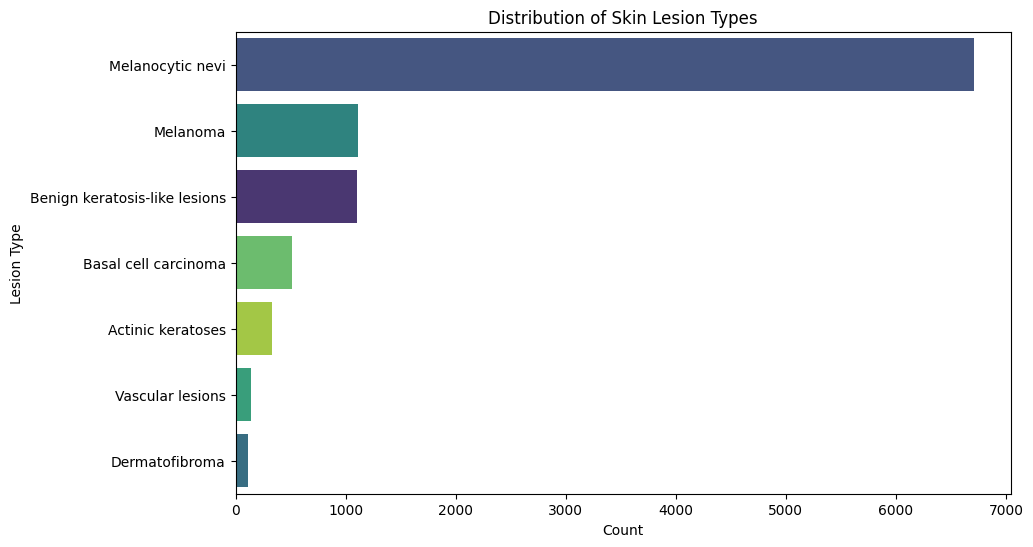

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Distribution of Cell Types:")
display(df_original['cell_type'].value_counts().to_frame())

plt.figure(figsize=(10, 6))
sns.countplot(y='cell_type', data=df_original, order=df_original['cell_type'].value_counts().index, palette='viridis', hue='cell_type', legend=False)
plt.title('Distribution of Skin Lesion Types')
plt.xlabel('Count')
plt.ylabel('Lesion Type')
plt.show()

Distribution of Age:


,age
count,10015.000000
mean,51.863828
std,16.920252
min,0.000000
25%,40.000000
50%,50.000000
75%,65.000000
max,85.000000


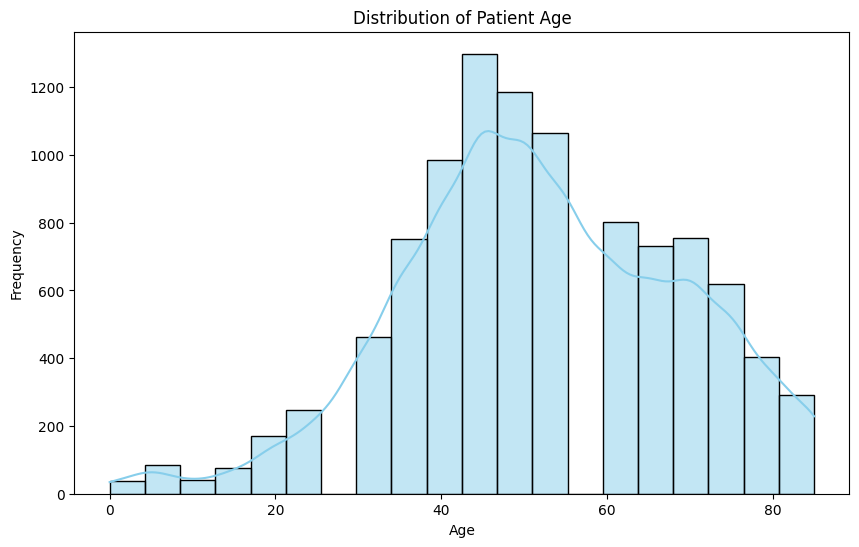

In [11]:
print("Distribution of Age:")
display(df_original['age'].describe().to_frame())

plt.figure(figsize=(10, 6))
sns.histplot(df_original['age'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Patient Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()


Distribution of Sex:


,count
sex,
male,5406
female,4552
unknown,57


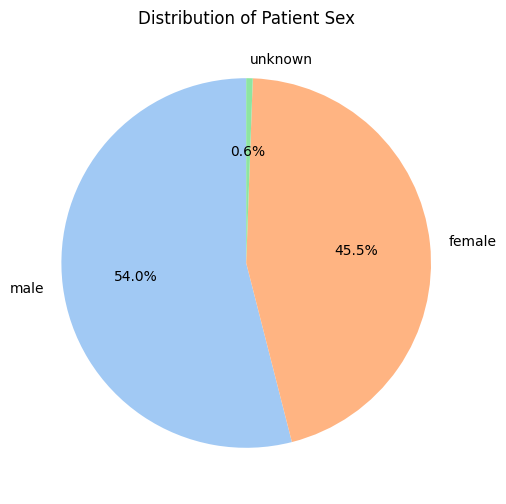

In [12]:
print("Distribution of Sex:")
display(df_original['sex'].value_counts().to_frame())

plt.figure(figsize=(6, 6))
df_original['sex'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Distribution of Patient Sex')
plt.ylabel('')
plt.show()


In [13]:
display(df_original.head())

,lesion_id,image_id,dx,dx_type,age,sex,localization,path,cell_type,cell_type_idx,sex_idx
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,/content/ham10000/ham10000_zip/HAM10000_images...,Benign keratosis-like lesions,2,1
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,/content/ham10000/ham10000_zip/HAM10000_images...,Benign keratosis-like lesions,2,1
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/content/ham10000/ham10000_zip/HAM10000_images...,Benign keratosis-like lesions,2,1
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,/content/ham10000/ham10000_zip/HAM10000_images...,Benign keratosis-like lesions,2,1
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,/content/ham10000/ham10000_zip/HAM10000_images...,Benign keratosis-like lesions,2,1


## Bölüm 5 — ITA Hesaplama ve Cilt Tipi Sınıflandırması

**⚠ KRİTİK SIRALAMA:** ITA hesaplaması veri bölünmesinden (train/val/test split) ÖNCE yapılmalıdır. Böylece `skin_type` sütunu tüm alt kümelere otomatik olarak taşınır ve bias analizinde kullanılabilir hale gelir.

In [14]:
from tqdm import tqdm
tqdm.pandas()

import cv2
import numpy as np
from skimage import color as skcolor


def calculate_ita_otsu(image_path):
    """
    Gelişmiş ITA hesaplama — Otsu tabanlı lezyon maskeleme.

    Mantık:
      1. Otsu eşikleme ile lezyonu (koyu/kontrastlı merkez) maskele.
      2. Maskenin DIŞINDA kalan 'sağlıklı deri' piksellerini kullan.
      3. Fazla karanlık veya yüksek saturasyonlu pikselleri filtrele.
      4. Ortalama L* ve b* üzerinden ITA hesapla.
    """
    try:
        img_bgr = cv2.imread(image_path)
        if img_bgr is None:
            return None
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        # 1. Lezyon maskesi: Otsu on grayscale + morfolojik kapatma
        gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
        blur = cv2.GaussianBlur(gray, (5, 5), 0)
        _, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
        lesion_mask = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

        # Maskeleme oranı güvenlik kontrolü
        mask_ratio = np.sum(lesion_mask > 0) / lesion_mask.size
        skin_mask = (lesion_mask == 0) if mask_ratio <= 0.70 else np.ones(gray.shape, dtype=bool)

        # 2. Sağlıklı deri pikselleri
        pixels = img_rgb[skin_mask]
        if len(pixels) < 50:
            return None

        # 3. Ek filtreleme
        brightness = pixels.sum(axis=1)
        pixels = pixels[brightness > 80]

        r = pixels[:, 0].astype(float)
        g = pixels[:, 1].astype(float)
        b = pixels[:, 2].astype(float)
        max_c = np.maximum(np.maximum(r, g), b)
        min_c = np.minimum(np.minimum(r, g), b)
        saturation = np.where(max_c > 0, (max_c - min_c) / max_c, 0.0)
        pixels = pixels[saturation < 0.45]

        if len(pixels) < 50:
            return None

        # 4. ITA = arctan((L* − 50) / b*) × 180/π
        avg_rgb = np.mean(pixels, axis=0) / 255.0
        lab = skcolor.rgb2lab(np.array([[avg_rgb]]))[0][0]
        L_star, b_star = lab[0], lab[2]

        if abs(b_star) < 1e-6:
            return None

        ita = float(np.arctan2((L_star - 50.0), b_star) * (180.0 / np.pi))
        return ita

    except Exception:
        return None


# Uygula
df_original['ita_value'] = df_original['path'].progress_apply(calculate_ita_otsu)


def classify_skin_type(ita):
    if ita is None:       return 'Unknown'
    if ita > 55:          return 'Very Light'
    elif 41 < ita <= 55:  return 'Light'
    elif 28 < ita <= 41:  return 'Intermediate'
    elif 10 < ita <= 28:  return 'Tan'
    elif -30 < ita <= 10: return 'Brown'
    else:                 return 'Dark'


df_original['skin_type'] = df_original['ita_value'].apply(classify_skin_type)
df_original.to_csv('/content/drive/MyDrive/df_original_ita.csv', index=False)
print("ITA cache Drive'a kaydedildi.")

print("ITA hesaplama tamamlandi (Otsu tabanli lezyon maskeleme).")
print(df_original['skin_type'].value_counts())


100%|██████████| 10015/10015 [06:25<00:00, 25.97it/s]


ITA cache Drive'a kaydedildi.
ITA hesaplama tamamlandi (Otsu tabanli lezyon maskeleme).
skin_type
Very Light      8535
Light           1072
Intermediate     371
Tan               25
Dark              10
Brown              2
Name: count, dtype: int64


Distribution of Skin Types:


,count
skin_type,
Very Light,8535
Light,1072
Intermediate,371
Tan,25
Dark,10
Brown,2


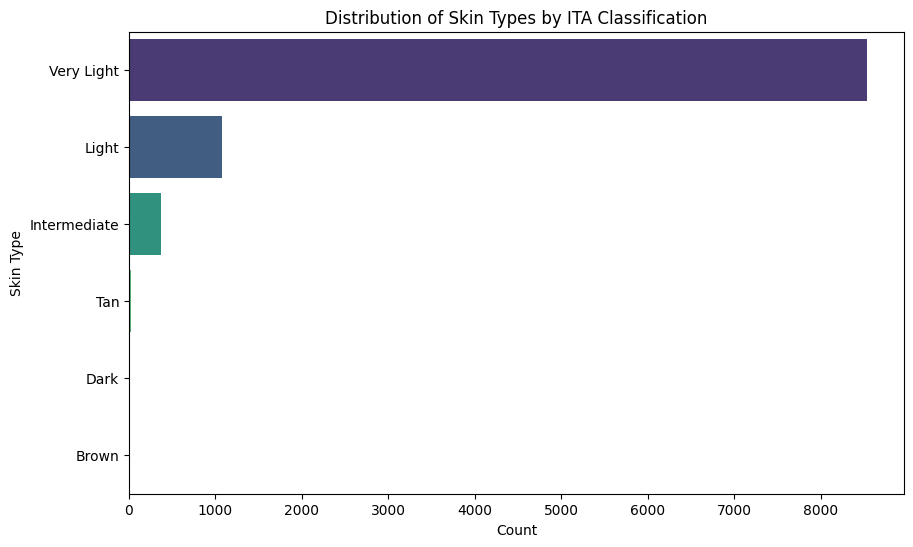

Distribution of ITA Values:


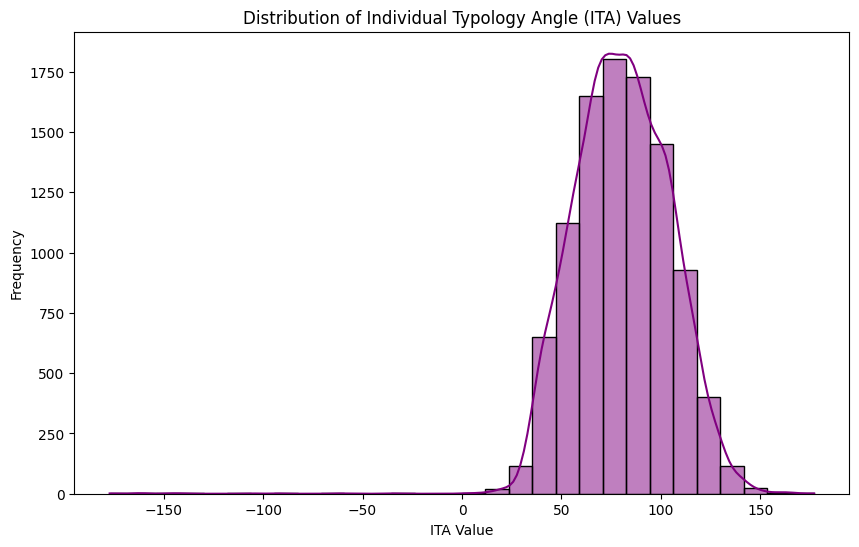

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Distribution of Skin Types:")
display(df_original['skin_type'].value_counts().to_frame())

plt.figure(figsize=(10, 6))
sns.countplot(y='skin_type', data=df_original, order=df_original['skin_type'].value_counts().index, palette='viridis', hue='skin_type', legend=False)
plt.title('Distribution of Skin Types by ITA Classification')
plt.xlabel('Count')
plt.ylabel('Skin Type')
plt.show()

print("Distribution of ITA Values:")
plt.figure(figsize=(10, 6))
sns.histplot(df_original['ita_value'].dropna(), bins=30, kde=True, color='purple')
plt.title('Distribution of Individual Typology Angle (ITA) Values')
plt.xlabel('ITA Value')
plt.ylabel('Frequency')
plt.show()

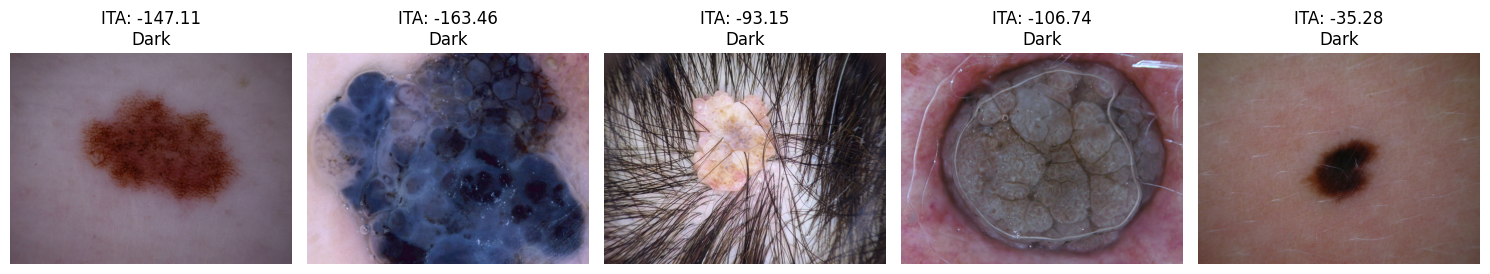

Yukarıdaki görseller 'Dark' olarak sınıflandırılan örneklerdir. Lütfen ITA fonksiyonunun maskeleme mantığının uygun olup olmadığını değerlendirin.


In [16]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# 'Dark' olarak sınıflandırılan resimlerden örnek al
dark_skin_samples = df_original[df_original['skin_type'] == 'Dark'].sample(n=5)

plt.figure(figsize=(15, 6))
for i, (index, row) in enumerate(dark_skin_samples.iterrows()):
    img_path = row['path']
    ita_value = row['ita_value']
    skin_type = row['skin_type']

    img = Image.open(img_path)

    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.title(f"ITA: {ita_value:.2f}\n{skin_type}")
    plt.axis('off')

plt.tight_layout()
plt.show()

print("Yukarıdaki görseller 'Dark' olarak sınıflandırılan örneklerdir. Lütfen ITA fonksiyonunun maskeleme mantığının uygun olup olmadığını değerlendirin.")

### Analyze Disease Distribution by Skin Type

Disease Distribution by Skin Type:


cell_type,Actinic keratoses,Basal cell carcinoma,Benign keratosis-like lesions,Dermatofibroma,Melanocytic nevi,Melanoma,Vascular lesions
skin_type,,,,,,,
Brown,0,0,0,0,2,0,0
Dark,0,0,1,0,6,3,0
Intermediate,0,3,12,1,346,7,2
Light,10,23,32,4,964,36,3
Tan,0,0,2,0,19,3,1
Very Light,317,488,1052,110,5368,1064,136


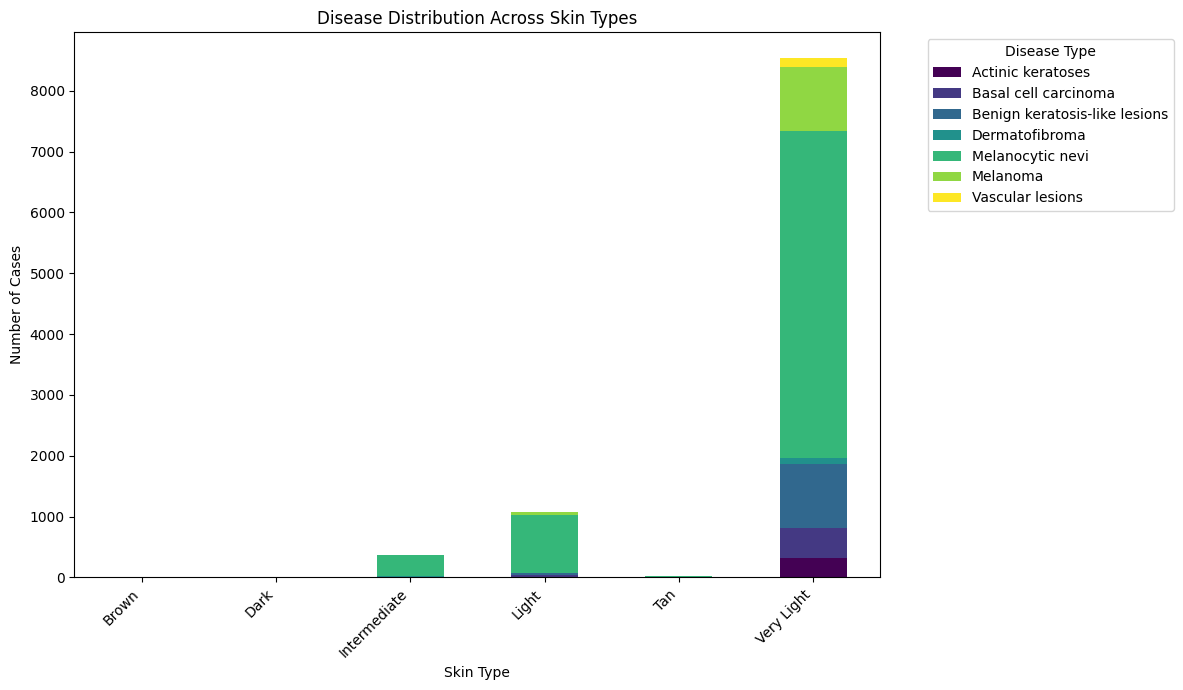

In [17]:
print("Disease Distribution by Skin Type:")
skin_type_disease_counts = pd.crosstab(df_original['skin_type'], df_original['cell_type'])
display(skin_type_disease_counts)

# Plotting the distribution
skin_type_disease_counts.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='viridis')
plt.title('Disease Distribution Across Skin Types')
plt.xlabel('Skin Type')
plt.ylabel('Number of Cases')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Disease Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Bölüm 6 — Mükerrer Kayıt Kontrolü ve Veri Bölme

Aynı hastaya ait görüntülerin (`lesion_id`) train ve val setlerine dağılması engellenir (data leakage önleme). Ardından stratified split uygulanır.

In [18]:
df_undup = df_original.groupby('lesion_id').count()
df_undup = df_undup[df_undup['image_id'] == 1]
df_undup.reset_index(inplace=True)
df_undup.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,path,cell_type,cell_type_idx,sex_idx,ita_value,skin_type
0,HAM_0000001,1,1,1,1,1,1,1,1,1,1,1,1
1,HAM_0000003,1,1,1,1,1,1,1,1,1,1,1,1
2,HAM_0000004,1,1,1,1,1,1,1,1,1,1,1,1
3,HAM_0000007,1,1,1,1,1,1,1,1,1,1,1,1
4,HAM_0000008,1,1,1,1,1,1,1,1,1,1,1,1


In [20]:
def get_duplicates(x):
    unique_list = list(df_undup['lesion_id'])
    if x in unique_list:
        return 'unduplicated'
    else:
        return 'duplicated'

# create a new column that is a copy of the lesion_id column
df_original['duplicates'] = df_original['lesion_id']
# apply the function to this new column
df_original['duplicates'] = df_original['duplicates'].apply(get_duplicates)
df_original.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,path,cell_type,cell_type_idx,sex_idx,ita_value,skin_type,duplicates
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,/content/ham10000/ham10000_zip/HAM10000_images...,Benign keratosis-like lesions,2,1,104.266187,Very Light,duplicated
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,/content/ham10000/ham10000_zip/HAM10000_images...,Benign keratosis-like lesions,2,1,103.132644,Very Light,duplicated
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/content/ham10000/ham10000_zip/HAM10000_images...,Benign keratosis-like lesions,2,1,95.538861,Very Light,duplicated
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,/content/ham10000/ham10000_zip/HAM10000_images...,Benign keratosis-like lesions,2,1,89.197325,Very Light,duplicated
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,/content/ham10000/ham10000_zip/HAM10000_images...,Benign keratosis-like lesions,2,1,98.233214,Very Light,duplicated


In [22]:
df_original['duplicates'].value_counts()

,count
duplicates,
unduplicated,5514
duplicated,4501


In [23]:
# now we filter out images that don't have duplicates
df_undup = df_original[df_original['duplicates'] == 'unduplicated']
df_undup.shape

(5514, 14)

In [24]:
# Koyu ten örneklerini ayır — test setine zorla gidecek
DARK_SKIN_LABELS = ['Dark', 'Brown']
df_dark_reserved = df_undup[df_undup['skin_type'].isin(DARK_SKIN_LABELS)].copy()
df_rest          = df_undup[~df_undup['skin_type'].isin(DARK_SKIN_LABELS)].copy()

print(f"Koyu ten (zorla test): {len(df_dark_reserved)} örnek  "
      f"(Dark={( df_dark_reserved['skin_type']=='Dark').sum()}, "
      f"Brown={(df_dark_reserved['skin_type']=='Brown').sum()})")

y_rest = df_rest['cell_type_idx']
_, df_val_rest = train_test_split(df_rest, test_size=0.2, random_state=101, stratify=y_rest)

df_val = pd.concat([df_val_rest, df_dark_reserved], ignore_index=True)
print(f"df_val toplam: {len(df_val)}")
print(df_val['skin_type'].value_counts())

Koyu ten (zorla test): 3 örnek  (Dark=1, Brown=2)
df_val toplam: 1106
skin_type
Very Light      832
Light           196
Intermediate     73
Tan               2
Brown             2
Dark              1
Name: count, dtype: int64


In [25]:
df_val['cell_type_idx'].value_counts()

,count
cell_type_idx,
4,886
2,88
5,46
1,35
0,30
6,13
3,8


In [26]:
# This set will be df_original excluding all rows that are in the val set
# This function identifies if an image is part of the train or val set.
def get_val_rows(x):
    # create a list of all the lesion_id's in the val set
    val_list = list(df_val['image_id'])
    if str(x) in val_list:
        return 'val'
    else:
        return 'train'

# identify train and val rows
# create a new colum that is a copy of the image_id column
df_original['train_or_val'] = df_original['image_id']
# apply the function to this new column
df_original['train_or_val'] = df_original['train_or_val'].apply(get_val_rows)
# filter out train rows
df_train = df_original[df_original['train_or_val'] == 'train']
print(len(df_train))
print(len(df_val))

8909
1106


In [27]:
df_train['cell_type_idx'].value_counts()

,count
cell_type_idx,
4,5819
5,1067
2,1011
1,479
0,297
6,129
3,107


In [28]:
df_val['cell_type'].value_counts()

,count
cell_type,
Melanocytic nevi,886
Benign keratosis-like lesions,88
Melanoma,46
Basal cell carcinoma,35
Actinic keratoses,30
Vascular lesions,13
Dermatofibroma,8


## Bölüm 7 — Veri Dengeleme (Oversampling)

Azınlık sınıfları `data_aug_rate` oranında kopyalanarak train seti dengelenir. HAM10000 gibi dengesiz veri setlerinde bu adım model başarısını doğrudan etkiler.

### Data Augmentation Techniques

The instructions from the user indicate to implement color and contrast-focused data augmentation techniques including Color Jittering, Histogram Equalization (specifically CLAHE), and optionally SMOTE. Since the model currently works on raw images, SMOTE is not directly applicable. I'll create a custom `CLAHETransform` and integrate `ColorJitter` into the `train_transform`.

In [29]:
# Copy fewer class to balance the number of 7 classes
data_aug_rate = [15,10,5,50,0,5,40]

df_train_augmented_parts = [df_train]

for i in range(7):
    if data_aug_rate[i] > 0:
        class_df = df_train.loc[df_train['cell_type_idx'] == i,:]
        # Add (data_aug_rate[i] - 1) additional copies of this class
        df_train_augmented_parts.extend([class_df] * (data_aug_rate[i] - 1))

df_train = pd.concat(df_train_augmented_parts, ignore_index=True)
df_train['cell_type'].value_counts()

,count
cell_type,
Melanocytic nevi,5819
Dermatofibroma,5350
Melanoma,5335
Vascular lesions,5160
Benign keratosis-like lesions,5055
Basal cell carcinoma,4790
Actinic keratoses,4455


In [30]:
# # We can split the test set again in a validation set and a true test set:
# df_val, df_test = train_test_split(df_val, test_size=0.5)
df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)
# df_test = df_test.reset_index()

In [31]:
# Koyu ten örnekleri direkt test'e, geri kalan stratify ile
df_val_dark   = df_val[df_val['skin_type'].isin(DARK_SKIN_LABELS)]
df_val_normal = df_val[~df_val['skin_type'].isin(DARK_SKIN_LABELS)]

y_val_normal = df_val_normal['cell_type_idx']
df_valid_normal, df_test_normal = train_test_split(
    df_val_normal, test_size=0.5, random_state=101, stratify=y_val_normal
)

df_valid = df_valid_normal.reset_index(drop=True)
df_test  = pd.concat([df_test_normal, df_val_dark], ignore_index=True).reset_index(drop=True)

print(f"df_train : {len(df_train)}")
print(f"df_valid : {len(df_valid)}")
print(f"df_test  : {len(df_test)}")
print("\ndf_test skin_type dağılımı:")
print(df_test['skin_type'].value_counts())

df_train : 35964
df_valid : 551
df_test  : 555

df_test skin_type dağılımı:
skin_type
Very Light      421
Light            98
Intermediate     33
Brown             2
Dark              1
Name: count, dtype: int64


## Bölüm 8 — Görüntü İşleme Sınıfları

Tüm transform sınıfları burada tanımlanır:
- **`HairRemovalTransform`**: LAB uzayında Blackhat morfoloji + TELEA inpainting ile tüy temizleme
- **`CLAHETransform`**: L kanalında lokal kontrast iyileştirme
- **`AlbumentationsWrapper`**: Albumentations transform'larını torchvision ile uyumlu hale getirir

In [32]:
!pip install -q albumentations

In [33]:
import albumentations as A
import numpy as np # AlbumentationsWrapper uses numpy
from PIL import Image # AlbumentationsWrapper uses PIL.Image
import cv2
from torchvision import transforms

class HairRemovalTransform:
    def __init__(self, max_mask_ratio=0.30, debug=False):
        self.max_mask_ratio = max_mask_ratio
        self.debug = debug

    def _get_kernel_size(self, shape):
        return 9 # Fixed kernel size as per suggestion

    def __call__(self, img_pil):
        img_cv = cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)

        h, w, _ = img_cv.shape

        # 1. Dinamik kernel boyutu (now fixed)
        k = self._get_kernel_size(img_cv.shape)
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (k, k))

        # 2. Renk Uzayı Değişimi (CIE Lab*) - L kanalı üzerinde işlem yap
        lab_img = cv2.cvtColor(img_cv, cv2.COLOR_BGR2LAB)
        L_channel, a_channel, b_channel = cv2.split(lab_img)

        # 3. Median Blur ile Ön Filtreleme (Gürültü Engelleme)
        # Apply median blur to L_channel before blackhat
        L_channel_blurred = cv2.medianBlur(L_channel, 3) # Using a 3x3 kernel for median blur

        # 4. Blackhat dönüşümü L kanalı üzerinde (blurred L_channel kullanıldı)
        blackhat_L = cv2.morphologyEx(L_channel_blurred, cv2.MORPH_BLACKHAT, kernel)

        # 5. Dinamik Eşikleme (Lezyon Kontrastına Göre)
        # Otsu eşikleme blackhat_L üzerinde
        otsu_val_L, thresh_L = cv2.threshold(
            blackhat_L, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
        )

        # L kanalının standart sapmasını hesapla (görüntü kontrastı için bir gösterge)
        L_std = np.std(L_channel) # Use original L_channel for std dev calculation
        if self.debug:
            print(f"L Channel Std Dev: {L_std:.2f}, Otsu threshold (L): {otsu_val_L:.1f}")

        L_std_threshold = 20
        min_blackhat_threshold_for_low_std = 25

        if L_std < L_std_threshold and otsu_val_L < min_blackhat_threshold_for_low_std:
            _, thresh = cv2.threshold(blackhat_L, min_blackhat_threshold_for_low_std, 255, cv2.THRESH_BINARY)
            if self.debug:
                print(f"Applying dynamic threshold: {min_blackhat_threshold_for_low_std} due to low L_std")
        elif otsu_val_L < 20:
            _, thresh = cv2.threshold(blackhat_L, 20, 255, cv2.THRESH_BINARY)
        else:
            thresh = thresh_L

        # 6. Maskeyi genişlet (kernel boyutu 5x5'ten 3x3'e düşürüldü)
        kernel_d = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
        mask = cv2.dilate(thresh, kernel_d, iterations=1)

        # 7. Mask güvenlik kontrolü
        mask_ratio = np.sum(mask > 0) / mask.size
        if self.debug:
            print(f"Mask ratio: {mask_ratio:.3f}")

        if mask_ratio > self.max_mask_ratio:
            return img_pil

        # 8. Dinamik inpaint yarıçapı (now fixed to 1)
        # inpaint_radius = 3 if mask_ratio < 0.05 else 5
        inpaint_radius = 1 # Fixed inpaint radius as per suggestion

        # 9. L kanalına inpaint uygula
        inpainted_L = cv2.inpaint(L_channel, mask, inpaint_radius, cv2.INPAINT_TELEA)

        # 10. İşlenmiş L kanalı ile orijinal a ve b kanallarını birleştir
        dst_lab = cv2.merge([inpainted_L, a_channel, b_channel])

        # 11. LAB'dan BGR'ye ve sonra RGB'ye dönüştür
        dst_bgr = cv2.cvtColor(dst_lab, cv2.COLOR_LAB2BGR)

        return Image.fromarray(cv2.cvtColor(dst_bgr, cv2.COLOR_BGR2RGB))

class AlbumentationsWrapper:
    def __init__(self, album_transform):
        self.album_transform = album_transform

    def __call__(self, img_pil):
        # Convert PIL Image to numpy array
        img_np = np.array(img_pil)
        # Apply Albumentations transform
        augmented_np = self.album_transform(image=img_np)['image']
        # Convert numpy array back to PIL Image
        return Image.fromarray(augmented_np)

class CLAHETransform:
    def __init__(self, clipLimit=2.0, tileGridSize=(8, 8)):
        self.clahe = cv2.createCLAHE(clipLimit=clipLimit, tileGridSize=tileGridSize)

    def __call__(self, img_pil):
        # Convert PIL Image to OpenCV format (numpy array)
        img_cv = np.array(img_pil)

        # Convert RGB to LAB for CLAHE (CLAHE works best on L channel)
        img_lab = cv2.cvtColor(img_cv, cv2.COLOR_RGB2LAB)
        L_channel, a_channel, b_channel = cv2.split(img_lab)

        # Apply CLAHE to the L-channel
        clahe_L = self.clahe.apply(L_channel)

        # Merge the enhanced L-channel with original a and b channels
        merged_lab = cv2.merge([clahe_L, a_channel, b_channel])

        # Convert back to RGB
        img_clahe_rgb = cv2.cvtColor(merged_lab, cv2.COLOR_LAB2RGB)

        # Convert back to PIL Image
        return Image.fromarray(img_clahe_rgb)

# ── Standart augmentasyon (tüm eğitim seti) ─────────────────────────────────
albumentations_augmentations = A.Compose([
    A.RandomToneCurve(scale=0.2, p=0.7),
    A.RGBShift(r_shift_limit=(-25, 0), g_shift_limit=(-25, 0), b_shift_limit=(-25, 0), p=0.7),
])

# ── Agresif koyu-ten augmentasyonu (Dark / Brown örnekler için) ───────────────
# Bu pipeline, koyu tenli az-temsilli örnekleri çok daha çeşitli hale getirir.
dark_skin_augmentations = A.Compose([
    # Ton eğrisini daha güçlü manipüle et
    A.RandomToneCurve(scale=0.45, p=0.9),
    # Kırmızı/yeşil/mavi kanalları negatif yönde kaydır → daha koyu görünüm
    A.RGBShift(
        r_shift_limit=(-40, -10),
        g_shift_limit=(-35, -10),
        b_shift_limit=(-30, -5),
        p=0.9
    ),
    # Gamma düzeltmesi: düşük gamma → daha koyu piksel değerleri
    A.RandomGamma(gamma_limit=(40, 80), p=0.8),
    # Hafif bulanıklık: farklı kamera koşullarını simüle et
    A.GaussianBlur(blur_limit=(3, 5), p=0.4),
    # Renk kanalları arasında hafif kayma
    A.HueSaturationValue(
        hue_shift_limit=10,
        sat_shift_limit=(-20, 10),
        val_shift_limit=(-30, -5),
        p=0.7
    ),
])


class DarkSkinAugTransform:
    """Dark/Brown tenli görüntülere agresif augmentasyon uygular."""
    def __init__(self, album_transform):
        self.wrapper = AlbumentationsWrapper(album_transform)

    def __call__(self, img_pil):
        return self.wrapper(img_pil)


# ── Transform pipeline'ları ──────────────────────────────────────────────────

# 1. Standart eğitim transform'u (tüm eğitim verisi)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    HairRemovalTransform(),
    transforms.ColorJitter(brightness=(0.5, 1.0), contrast=(0.8, 1.2), saturation=(0.8, 1.2)),
    AlbumentationsWrapper(albumentations_augmentations),
    CLAHETransform(),
    transforms.ToTensor(),
    transforms.Normalize(mean=norm_mean, std=norm_std)
])

# 2. Koyu ten agresif augmentasyon transform'u (Dark + Brown alt-kümesi)
dark_skin_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    HairRemovalTransform(),
    DarkSkinAugTransform(dark_skin_augmentations),
    CLAHETransform(),
    transforms.ToTensor(),
    transforms.Normalize(mean=norm_mean, std=norm_std)
])

# Validation and Test Transformations (without Data Augmentation, but with Normalization)
# For validation/test, only deterministic preprocessing steps should be applied.
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)), # Resize images to 224x224
    HairRemovalTransform(), # Add hair removal as a preprocessing step
    CLAHETransform(), # Apply CLAHE for consistency with training preprocessing
    transforms.ToTensor(), # Convert PIL image to PyTorch tensor (and scales to 0-1)
    transforms.Normalize(mean=norm_mean, std=norm_std) # Normalize with pre-calculated mean and std
])

print("Transformations defined with HairRemovalTransform, more aggressive ColorJitter, Albumentations (RandomToneCurve, RGBShift), and CLAHETransform.")

Transformations defined with HairRemovalTransform, more aggressive ColorJitter, Albumentations (RandomToneCurve, RGBShift), and CLAHETransform.


### HairRemovalTransform Görsel Testi

Processing image: ISIC_0031381.jpg
L Channel Std Dev: 19.30, Otsu threshold (L): 4.0
Applying dynamic threshold: 25 due to low L_std
Mask ratio: 0.002
Processing image: ISIC_0032644.jpg
L Channel Std Dev: 46.89, Otsu threshold (L): 5.0
Mask ratio: 0.002
Processing image: ISIC_0033556.jpg
L Channel Std Dev: 26.71, Otsu threshold (L): 6.0
Mask ratio: 0.026
Processing image: ISIC_0030522.jpg
L Channel Std Dev: 45.83, Otsu threshold (L): 39.0
Mask ratio: 0.122
Processing image: ISIC_0029636.jpg
L Channel Std Dev: 19.55, Otsu threshold (L): 3.0
Applying dynamic threshold: 25 due to low L_std
Mask ratio: 0.003


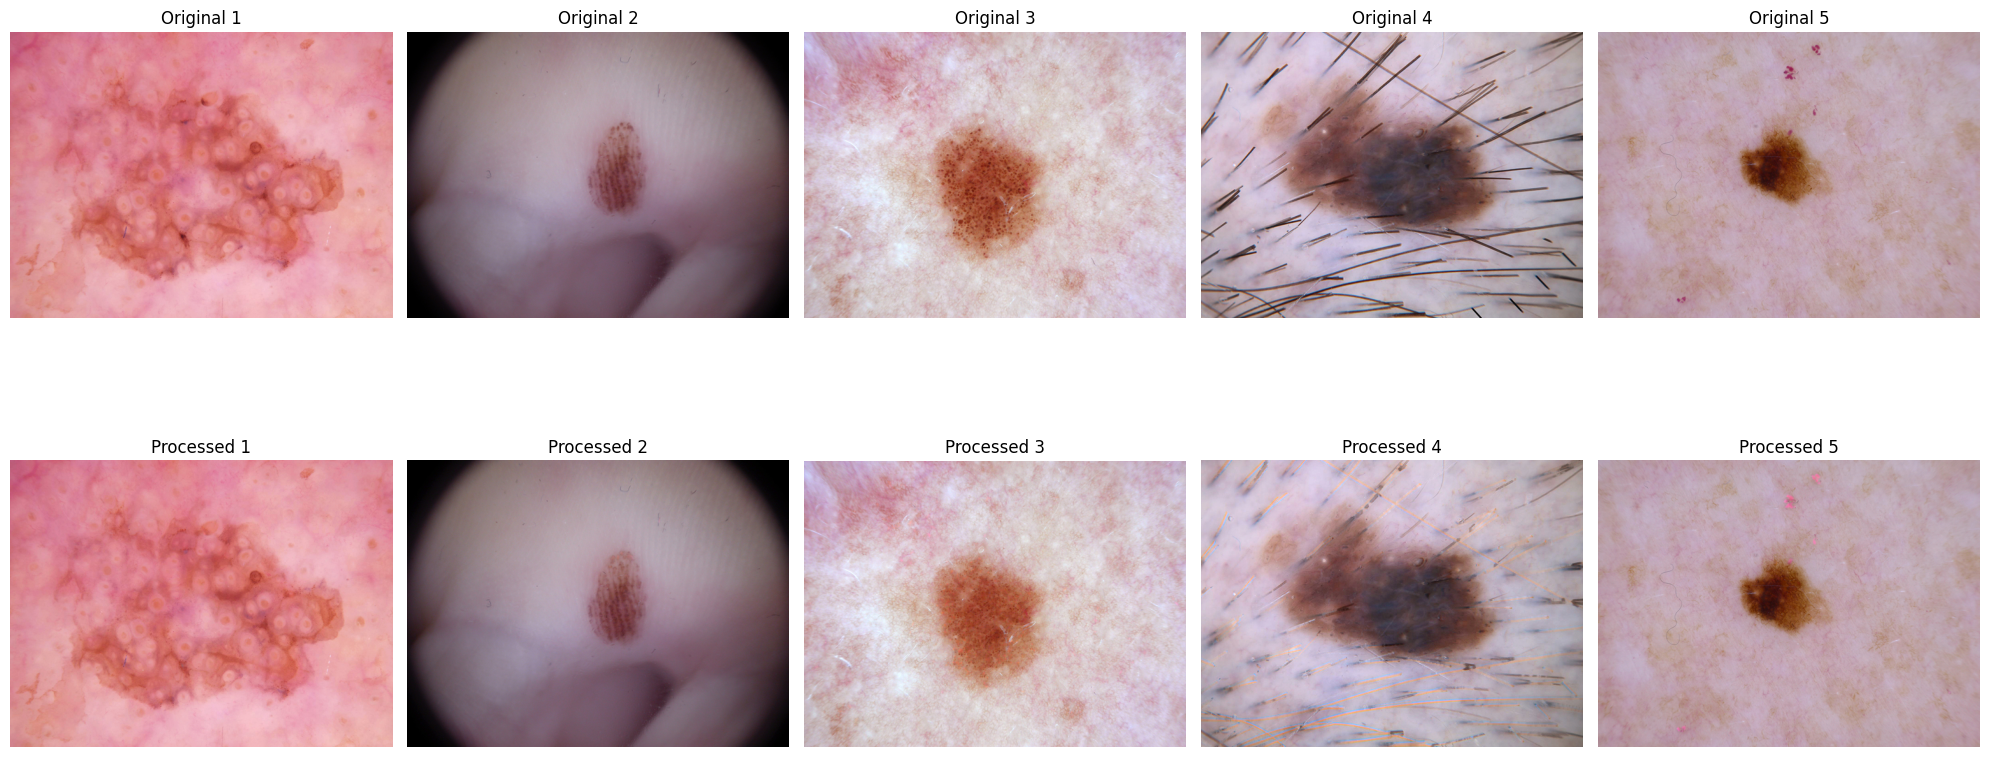

Visual inspection complete. Please check the images above to assess the hair removal process.


In [34]:
import matplotlib.pyplot as plt
from PIL import Image
import random

# Instantiate the HairRemovalTransform with debug mode enabled
hair_removal_debug_transform = HairRemovalTransform(debug=True)

# Get a few random image paths from the original dataframe
sample_image_paths = df_original['path'].sample(5).tolist()

plt.figure(figsize=(20, 10))

for i, img_path in enumerate(sample_image_paths):
    # Load the original image
    original_image = Image.open(img_path).convert("RGB")

    # Apply the hair removal transform
    print(f"Processing image: {img_path.split('/')[-1]}")
    processed_image = hair_removal_debug_transform(original_image)

    # Display original image
    plt.subplot(2, 5, i + 1)
    plt.imshow(original_image)
    plt.title(f"Original {i+1}")
    plt.axis('off')

    # Display processed image
    plt.subplot(2, 5, i + 6) # i + 1 + 5 (for second row)
    plt.imshow(processed_image)
    plt.title(f"Processed {i+1}")
    plt.axis('off')

plt.tight_layout()
plt.show()

print("Visual inspection complete. Please check the images above to assess the hair removal process.")

### Albumentations Entegrasyonu: RandomToneCurve ve RGBShift

`Albumentations`, derin öğrenme modelleri için popüler ve hızlı bir görüntü artırma kütüphanesidir. Özellikle medikal görüntülerde dokuyu bozmadan renk ve kontrast ayarlamaları yapmak için çok kullanışlı fonksiyonlar sunar. Kullanıcının talebi doğrultusunda, renkleri koyulaştırmak ve kontrastı değiştirmek için `RandomToneCurve` ve `RGBShift` fonksiyonlarını kullanacağız.

- **`RandomToneCurve`**: Görüntünün ton eğrisini rastgele değiştirerek parlaklık ve kontrastta ince ayarlar yapar. Bu, görüntülerin genel parlaklığını ve ton dağılımını etkileyerek daha koyu görünümler elde etmemize yardımcı olur.
- **`RGBShift`**: Her bir RGB kanalının değerlerini bağımsız olarak hafifçe kaydırarak renk dengesinde değişiklikler yaratır. Negatif kaydırma limitleri kullanarak renkleri genel olarak koyulaştırabiliriz.

Bu transformasyonları `torchvision.transforms.Compose` ile uyumlu hale getirmek için, `Albumentations` dönüşümlerini bir `numpy` array üzerinde uygulayıp sonra tekrar `PIL Image`'e dönüştüren bir sarıcı (`wrapper`) sınıf oluşturacağız.

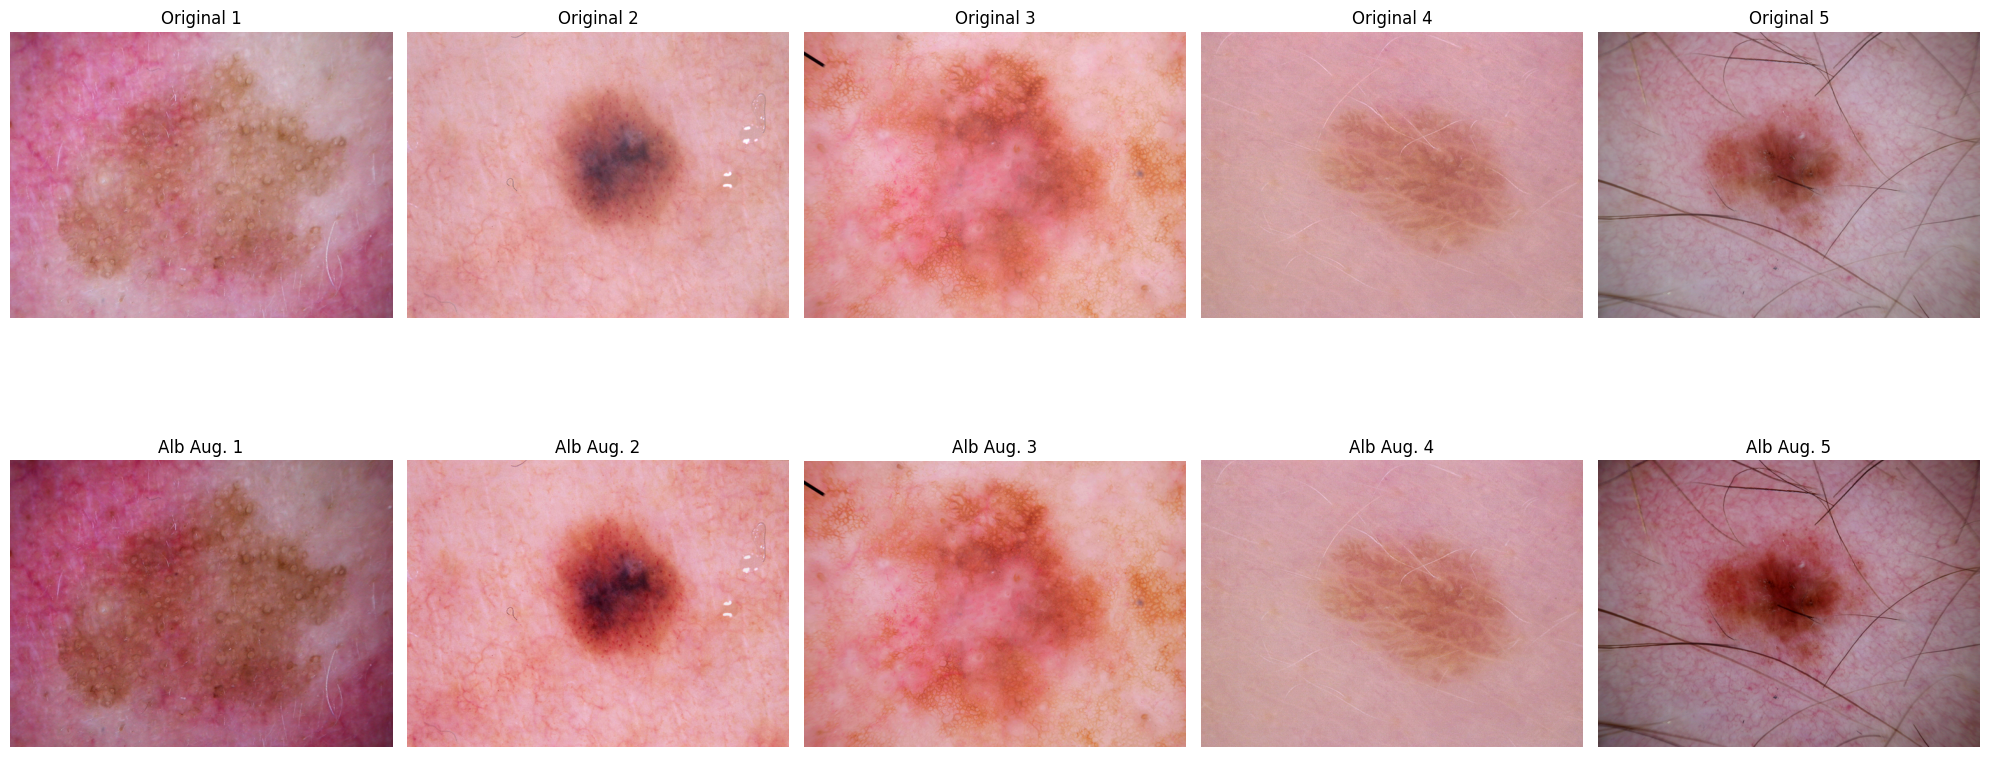

Visual inspection of Albumentations (RandomToneCurve, RGBShift) effect complete.


In [35]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import numpy as np
import albumentations as A

# Define a temporary Albumentations-only transform for visualization
temp_alb_transform = A.Compose([
    A.RandomToneCurve(scale=0.1, p=1.0), # Force apply for visualization
    A.RGBShift(r_shift_limit=(-20, -10), g_shift_limit=(-20, -10), b_shift_limit=(-20, -10), p=1.0) # Force apply and slightly stronger shift for clear visualization
])

# Get a few random image paths from the original dataframe
sample_image_paths = df_original['path'].sample(5, random_state=42).tolist()

plt.figure(figsize=(20, 10))

for i, img_path in enumerate(sample_image_paths):
    # Load the original image
    original_image_pil = Image.open(img_path).convert("RGB")
    original_image_np = np.array(original_image_pil)

    # Apply the Albumentations-only transform
    processed_image_np = temp_alb_transform(image=original_image_np)['image']
    processed_image_pil = Image.fromarray(processed_image_np)

    # Display original image
    plt.subplot(2, 5, i + 1)
    plt.imshow(original_image_pil)
    plt.title(f"Original {i+1}")
    plt.axis('off')

    # Display processed image
    plt.subplot(2, 5, i + 6) # i + 1 + 5 (for second row)
    plt.imshow(processed_image_pil)
    plt.title(f"Alb Aug. {i+1}")
    plt.axis('off')

plt.tight_layout()
plt.show()

print("Visual inspection of Albumentations (RandomToneCurve, RGBShift) effect complete.")

### CustomImageDataset Tanımlama

Bu sınıf, PyTorch'un `Dataset` soyut sınıfından türetilmiştir ve veri yükleme pipeline'ınızın temelini oluşturur. Görevi, veriyi (görüntüler, etiketler ve meta veriler) modelin tüketebileceği formatta hazırlamaktır. Özellikle:

- `__init__`: Veri çerçevesini (`data_frame`) ve isteğe bağlı dönüşümleri (`transform`) başlatır.
- `__len__`: Veri kümesindeki toplam öğe sayısını döndürür.
- `__getitem__`: Belirtilen indeksteki bir örneği (görüntü, etiket, meta veri) yükler, ön işleme tabi tutar ve döndürür.
  - **Resmi Hazırla**: Görüntüyü yolundan okur, RGB'ye dönüştürür ve tanımlanan dönüşümleri uygular.
  - **Etiketi Hazırla**: DataFrame'den etiketi alır ve PyTorch tensor'una dönüştürür.
  - **Meta Verileri Hazırla**: Yaş ve cinsiyet indeksini birleştirerek bir meta veri tensörü oluşturur. Bu, modelin yalnızca görüntüyü değil, aynı zamanda ek hasta bilgilerini de dikkate almasını sağlar.

In [36]:
from torch.utils.data import Dataset

class CustomImageDataset(Dataset):
    def __init__(self, data_frame, transform=None):
        self.df = data_frame.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # 1. Resmi Hazırla
        img_path = self.df['path'].iloc[idx]  # 'path' sütunu kullanılıyor
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        # 2. Etiketi Hazırla
        label = torch.tensor(self.df['cell_type_idx'].iloc[idx], dtype=torch.long)

        # 3. Meta Verileri Hazırla (Modelin beklediği vektör)
        # Yaş ve Cinsiyeti bir tensor yapıyoruz
        meta_data = torch.tensor([
            self.df['age'].iloc[idx],
            self.df['sex_idx'].iloc[idx]
        ], dtype=torch.float32)

        # 4. Cilt Tipi (bias analizi ve ISLT için)
        skin_type = self.df['skin_type'].iloc[idx] if 'skin_type' in self.df.columns else 'Unknown'

        return image, meta_data, label, skin_type

print("CustomImageDataset tanımlandı (skin_type dahil).")


CustomImageDataset tanımlandı (skin_type dahil).


## Bölüm 10 — DataLoader Oluşturma

`num_workers=0`: Colab'da multiprocessing spawn hatasını önler.

In [37]:
from torch.utils.data import DataLoader, WeightedRandomSampler
import numpy as np

BATCH_SIZE = 32

# ── Dataset örnekleri ────────────────────────────────────────────────────────
train_dataset = CustomImageDataset(data_frame=df_train, transform=train_transform)
valid_dataset = CustomImageDataset(data_frame=df_valid, transform=val_test_transform)
test_dataset  = CustomImageDataset(data_frame=df_test,  transform=val_test_transform)

# ── Fair-Batching: ITA grubuna göre WeightedRandomSampler ────────────────────
# Her örneğin agirliği = 1 / (kendi ITA grubundaki örnek sayisi)
# Böylece her batch'te Very Light → Dark tüm gruplar dengeli temsil edilir.

ITA_GROUPS = ['Very Light', 'Light', 'Intermediate', 'Tan', 'Brown', 'Dark', 'Unknown']

skin_types_train = df_train['skin_type'].values
group_counts = {g: int(max((skin_types_train == g).sum(), 1)) for g in ITA_GROUPS}

sample_weights = np.array(
    [1.0 / group_counts.get(st, 1) for st in skin_types_train],
    dtype=np.float64
)

fair_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

print("Fair-Batching agirliklari hesaplandi:")
for g in ITA_GROUPS:
    cnt = group_counts.get(g, 0)
    w   = 1.0 / max(cnt, 1)
    print(f"  {g:15s}: {cnt:5d} örnek  ->  agirlik = {w:.6f}")

# ── DataLoader'lar ────────────────────────────────────────────────────────────
# train_dataloader: shuffle=False — sampler ile çelişir
train_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=fair_sampler,
    num_workers=0
)
valid_dataloader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_dataloader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("\nDataLoader'lar olusturuldu (Fair-Batching aktif).")
print(f"  train batches : {len(train_dataloader)}")
print(f"  valid batches : {len(valid_dataloader)}")
print(f"  test  batches : {len(test_dataloader)}")


Fair-Batching agirliklari hesaplandi:
  Very Light     : 33639 örnek  ->  agirlik = 0.000030
  Light          :  1737 örnek  ->  agirlik = 0.000576
  Intermediate   :   489 örnek  ->  agirlik = 0.002045
  Tan            :    74 örnek  ->  agirlik = 0.013514
  Brown          :     1 örnek  ->  agirlik = 1.000000
  Dark           :    25 örnek  ->  agirlik = 0.040000
  Unknown        :     1 örnek  ->  agirlik = 1.000000

DataLoader'lar olusturuldu (Fair-Batching aktif).
  train batches : 1124
  valid batches : 18
  test  batches : 18


### Koyu Ten Alt-Kümesi — Agresif Augmentasyon ile Birleştirme

`Dark` ve `Brown` örnekleri `dark_skin_transform` pipeline'ı ile ayrıca augmente edilip
ana eğitim setine (`ConcatDataset`) eklenir. `WeightedRandomSampler` her iki kaynaktan
da ITA-dengeli örnekleme yapar; bu sayede koyu tenli veri azlığı hem nicelik hem çeşitlilik açısından giderilir.

In [38]:
# ── Koyu tenli alt-küme: agresif augmentasyon ile dataset ────────────────────
from torch.utils.data import ConcatDataset

dark_skin_labels = ['Dark', 'Brown']
df_dark = df_train[df_train['skin_type'].isin(dark_skin_labels)].copy()
print(f"Koyu ten örnekleri (Dark+Brown): {len(df_dark)} adet")

if len(df_dark) > 0:
    dark_dataset = CustomImageDataset(data_frame=df_dark, transform=dark_skin_transform)

    # Ana train_dataset ile birleştir
    combined_train_dataset = ConcatDataset([train_dataset, dark_dataset])

    # Dark örnekleri için ağırlıklar (aynı ITA-grup ağırlığı)
    dark_weights = np.array(
        [1.0 / group_counts.get(st, 1) for st in df_dark['skin_type'].values],
        dtype=np.float64
    )
    combined_weights = np.concatenate([sample_weights, dark_weights])

    combined_sampler = WeightedRandomSampler(
        weights=combined_weights,
        num_samples=len(combined_weights),
        replacement=True
    )

    # train_dataloader'ı güncelle
    train_dataloader = DataLoader(
        combined_train_dataset,
        batch_size=BATCH_SIZE,
        sampler=combined_sampler,
        num_workers=0
    )
    print(f"Birlesik dataset boyutu : {len(combined_train_dataset)}")
    print(f"Güncellenmiş train batches: {len(train_dataloader)}")
else:
    print("Koyu ten örneği bulunamadı; orijinal train_dataloader kullanılıyor.")


Koyu ten örnekleri (Dark+Brown): 25 adet
Birlesik dataset boyutu : 35989
Güncellenmiş train batches: 1125


## Bölüm 11 — Model Tanımı — ResNetWithMetadata

ResNet50 backbone; backbone parametreleri başta tamamen dondurulmuştur. Sadece `fc_layers` eğitilir (baseline). ISLT aşamasında seçili katmanlar açılır.

In [39]:
import torch
import torch.nn as nn
from torchvision import models

# Check for GPU availability
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

class ResNetWithMetadata(nn.Module):
    def __init__(self, num_classes=7, metadata_size=2):
        super(ResNetWithMetadata, self).__init__()
        # 1. Load pre-trained ResNet50 model
        self.resnet = models.resnet50(pretrained=True)

        # 2. Freeze parameters of the ResNet50 backbone
        for param in self.resnet.parameters():
            param.requires_grad = False

        # ── Backbone: fc katmanını kaldır ama named layer'ları koru
        #    (layer4, layer3 vs. GradCAM için erişilebilir kalmalı)
        self.resnet.fc = nn.Identity()   # fc'yi sil, named attr'lar kalır
        # GlobalAvgPool çıktısı: (B, 2048, 1, 1) → flatten ile (B, 2048)

        # 3. Get the number of features from ResNet50's output
        # ResNet50's final average pooling layer outputs 2048 features
        resnet_output_features = 2048

        # 4. Define new fully connected layers
        # Input size combines ResNet features and metadata features
        combined_features_input_size = resnet_output_features + metadata_size

        self.fc_layers = nn.Sequential(
            nn.Linear(combined_features_input_size, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, image_input, meta_data_input):
        # 1. Pass image input through the frozen ResNet50 backbone
        image_features = self.resnet(image_input)   # (B, 2048) — fc=Identity
        # avgpool çıktısı (B,2048,1,1) olabilir; her iki durumu da karşıla
        if image_features.dim() == 4:
            image_features = torch.flatten(image_features, 1)

        # 3. Concatenate image features with meta_data input
        combined_features = torch.cat((image_features, meta_data_input), dim=1)

        # 4. Pass combined features through the newly defined fully connected layers
        output = self.fc_layers(combined_features)
        return output

# Instantiate the custom model
model = ResNetWithMetadata(num_classes=7, metadata_size=2)

# Move the model to the appropriate device
model = model.to(device)

print("ResNetWithMetadata model defined, instantiated, and moved to device.")
print(f"Model Architecture: {model}")

Using device: cuda:0


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 246MB/s]


ResNetWithMetadata model defined, instantiated, and moved to device.
Model Architecture: ResNetWithMetadata(
  (resnet): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_

## Bölüm 12 — Loss Fonksiyonu ve Optimizer

In [40]:
import torch.optim as optim

# Define the Loss Function
# For multi-class classification, CrossEntropyLoss is a standard choice.
# It combines LogSoftmax and NLLLoss in one single class.
criterion = nn.CrossEntropyLoss()

# Define the Optimizer
# Adam optimizer is a popular choice for its efficiency and good performance.
# We will optimize only the parameters that are not frozen (i.e., the new FC layers).
optimizer = optim.Adam(model.fc_layers.parameters(), lr=0.001, weight_decay=1e-5)

# Learning Rate Scheduler (optional, but often helpful)
# ReduceLROnPlateau reduces the learning rate when a metric has stopped improving.
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)

print("Loss function (CrossEntropyLoss) and Optimizer (Adam) defined.")

Loss function (CrossEntropyLoss) and Optimizer (Adam) defined.


## Bölüm 13 — Eğitim ve Validasyon Fonksiyonları

`train_one_epoch` ve `validate_one_epoch` — F1, precision, recall metrikleri dahil. DataLoader'dan `(image, meta_data, label, skin_type)` dörtlüsünü alacak şekilde güncellenmiştir.

In [41]:
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, meta_data, labels, _ in dataloader:  # skin_type unpack edildi (_)
        images    = images.to(device)
        meta_data = meta_data.to(device)
        labels    = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images, meta_data)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    return epoch_loss, all_preds, all_labels


def validate_one_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, meta_data, labels, _ in dataloader:  # skin_type unpack edildi (_)
            images    = images.to(device)
            meta_data = meta_data.to(device)
            labels    = labels.to(device)

            outputs = model(images, meta_data)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs.data, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    return epoch_loss, all_preds, all_labels

print("Eğitim ve validasyon fonksiyonları tanımlandı.")


Eğitim ve validasyon fonksiyonları tanımlandı.


## Bölüm 14 — Baseline Eğitim

Tüm backbone katmanları dondurulmuş, yalnızca `fc_layers` eğitilir. Bu model ISLT karşılaştırması için referans noktasıdır. En iyi model `best_model_baseline.pth` olarak kaydedilir.

In [42]:
# 1. Modeli yükle (eğitim YOK)
model = ResNetWithMetadata(num_classes=7, metadata_size=2).to(device)
model.load_state_dict(torch.load('/content/drive/MyDrive/best_model_islt.pth'))
model.eval()
print("✓ ISLT modeli yüklendi")

✓ ISLT modeli yüklendi


In [ ]:
num_epochs = 10 # You can adjust the number of epochs

history = {
    'train_loss': [],
    'val_loss': [],
    'train_accuracy': [],
    'val_accuracy': [],
    'val_f1_macro': [], # Adding F1-score for validation
    'val_precision_macro': [], # Adding precision for validation
    'val_recall_macro': [] # Adding recall for validation
}

# Initialize best validation loss for saving model
best_val_loss = float('inf')

print("Starting training...")

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print("-" * 10)

    # Training phase
    train_loss, train_preds, train_labels = train_one_epoch(model, train_dataloader, criterion, optimizer, device)
    train_accuracy = (np.array(train_preds) == np.array(train_labels)).mean() * 100

    # Validation phase
    val_loss, val_preds, val_labels = validate_one_epoch(model, valid_dataloader, criterion, device)
    val_accuracy = (np.array(val_preds) == np.array(val_labels)).mean() * 100

    # Calculate F1-score, Precision, Recall for validation
    val_f1 = f1_score(val_labels, val_preds, average='macro', zero_division=0)
    val_precision = precision_score(val_labels, val_preds, average='macro', zero_division=0)
    val_recall = recall_score(val_labels, val_preds, average='macro', zero_division=0)

    print(f"Train Loss: {train_loss:.4f} Acc: {train_accuracy:.2f}%")
    print(f"Val Loss: {val_loss:.4f} Acc: {val_accuracy:.2f}% F1: {val_f1:.4f} P: {val_precision:.4f} R: {val_recall:.4f}")

    # Save metrics to history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_accuracy'].append(train_accuracy)
    history['val_accuracy'].append(val_accuracy)
    history['val_f1_macro'].append(val_f1)
    history['val_precision_macro'].append(val_precision)
    history['val_recall_macro'].append(val_recall)

    # Save the model if validation loss has improved
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), '/content/drive/MyDrive/best_model_baseline.pth')
        print(f"Saved best model with validation loss: {best_val_loss:.4f}")


print("Training complete.")

Starting training...

Epoch 1/10
----------
Train Loss: 0.5996 Acc: 79.78%
Val Loss: 0.5434 Acc: 80.22% F1: 0.3590 P: 0.4791 R: 0.3933
Saved best model with validation loss: 0.5434

Epoch 2/10
----------
Train Loss: 0.4797 Acc: 83.67%
Val Loss: 0.5243 Acc: 82.40% F1: 0.3582 P: 0.4566 R: 0.3730
Saved best model with validation loss: 0.5243

Epoch 3/10
----------
Train Loss: 0.4307 Acc: 85.49%
Val Loss: 0.5147 Acc: 81.31% F1: 0.3677 P: 0.3980 R: 0.4468
Saved best model with validation loss: 0.5147

Epoch 4/10
----------
Train Loss: 0.4177 Acc: 85.71%
Val Loss: 0.7555 Acc: 73.14% F1: 0.3575 P: 0.3784 R: 0.5307

Epoch 5/10
----------
Train Loss: 0.3930 Acc: 86.69%
Val Loss: 0.6609 Acc: 76.77% F1: 0.3784 P: 0.3839 R: 0.5343

Epoch 6/10
----------
Train Loss: 0.3840 Acc: 86.86%
Val Loss: 0.6208 Acc: 80.22% F1: 0.3932 P: 0.4929 R: 0.4904

Epoch 7/10
----------
Train Loss: 0.3780 Acc: 87.22%
Val Loss: 0.5182 Acc: 82.21% F1: 0.4209 P: 0.4714 R: 0.4693

Epoch 8/10
----------
Train Loss: 0.3706 A

In [43]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    plt.figure(figsize=(15, 5))

    # Plot Training & Validation Loss
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.title('Training & Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Plot Training & Validation Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history['train_accuracy'], label='Train Accuracy')
    plt.plot(history['val_accuracy'], label='Validation Accuracy')
    plt.title('Training & Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    # Optionally, plot F1-score, Precision, Recall
    if 'val_f1_macro' in history and len(history['val_f1_macro']) > 0:
        plt.figure(figsize=(15, 5))
        plt.plot(history['val_f1_macro'], label='Validation F1-Macro')
        plt.plot(history['val_precision_macro'], label='Validation Precision-Macro')
        plt.plot(history['val_recall_macro'], label='Validation Recall-Macro')
        plt.title('Validation Metrics (F1, Precision, Recall)')
        plt.xlabel('Epoch')
        plt.ylabel('Score')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()


plot_training_history(history)
print("Training history plots generated.")

NameError: name 'history' is not defined

## Bölüm 15 — Bias Analizi — Cilt Tipine Göre Model Performansı

Baseline modelin koyu tenli (Brown / Dark) örneklerde doğruluğu ölçülür. Bu analiz ISLT'de hangi katmanın açılacağını belirler.

In [57]:
import pandas as pd
from sklearn.metrics import classification_report, f1_score

model.eval()
all_preds_b  = []
all_labels_b = []
all_skin_b   = []

with torch.no_grad():
    for images, meta_data, labels, skin_types in test_dataloader:
        images    = images.to(device)
        meta_data = meta_data.to(device)
        labels    = labels.to(device)

        outputs = model(images, meta_data)
        _, predicted = torch.max(outputs, 1)

        all_preds_b.extend(predicted.cpu().numpy())
        all_labels_b.extend(labels.cpu().numpy())
        all_skin_b.extend(skin_types)

results_df = pd.DataFrame({
    'pred'      : all_preds_b,
    'label'     : all_labels_b,
    'skin_type' : all_skin_b
})
results_df['correct'] = (results_df['pred'] == results_df['label']).astype(int)

print("=== Cilt Tipine Göre Doğruluk (Baseline) ===")
print(results_df.groupby('skin_type')['correct'].mean().sort_values())

print("\n=== Koyu Ten (Brown + Dark) F1 ===")
dark_mask = results_df['skin_type'].isin(['Brown', 'Dark'])
dark_df   = results_df[dark_mask]
if len(dark_df) > 0:
    dark_f1 = f1_score(dark_df['label'], dark_df['pred'], average='macro', zero_division=0)
    print(f"Brown/Dark F1-macro : {dark_f1:.4f}")
    print(f"Örnek sayısı        : {len(dark_df)}")
else:
    print("Test setinde Brown/Dark örnek bulunamadı.")

print("\n=== Genel Sınıflandırma Raporu ===")
print(classification_report(results_df['label'], results_df['pred'], zero_division=0))


=== Cilt Tipine Göre Doğruluk (Baseline) ===
skin_type
Very Light      0.805226
Light           0.928571
Dark            1.000000
Brown           1.000000
Intermediate    1.000000
Name: correct, dtype: float64

=== Koyu Ten (Brown + Dark) F1 ===
Brown/Dark F1-macro : 1.0000
Örnek sayısı        : 3

=== Genel Sınıflandırma Raporu ===
              precision    recall  f1-score   support

           0       0.35      0.53      0.42        15
           1       0.44      0.39      0.41        18
           2       0.86      0.14      0.24        44
           3       0.00      0.00      0.00         4
           4       0.93      0.97      0.95       445
           5       0.27      0.30      0.29        23
           6       0.50      0.83      0.62         6

    accuracy                           0.84       555
   macro avg       0.48      0.45      0.42       555
weighted avg       0.85      0.84      0.82       555



In [58]:
# ── Kritik 4 — Equal Opportunity Difference (EOD) ───────────────────────────
# EOD = TPR_dark - TPR_light
# TPR (True Positive Rate / Recall) = TP / (TP + FN)
# Her sınıf için ayrı ayrı hesaplanır, sonra macro ortalaması alınır.
# Negatif EOD → model koyu tende daha kötü (bias var)
# EOD ≈ 0     → gruplar arası fırsat eşitliği sağlandı

from sklearn.metrics import recall_score
import numpy as np

def compute_eod(results_df, label='Baseline'):
    """results_df: pred, label, skin_type sütunlarını içermeli."""
    light_mask = results_df['skin_type'].isin(['Very Light', 'Light', 'Intermediate'])
    dark_mask  = results_df['skin_type'].isin(['Tan', 'Brown', 'Dark'])

    light_df = results_df[light_mask]
    dark_df  = results_df[dark_mask]

    if len(dark_df) == 0:
        print(f'[{label}] Koyu ten örneği yok — EOD hesaplanamadı.')
        return None

    tpr_light = recall_score(light_df['label'], light_df['pred'],
                              average='macro', zero_division=0)
    tpr_dark  = recall_score(dark_df['label'],  dark_df['pred'],
                              average='macro', zero_division=0)
    eod = tpr_dark - tpr_light

    print(f'\n=== EOD — {label} ===')
    print(f'  TPR Light/Intermediate : {tpr_light:.4f}  (n={len(light_df)})')
    print(f'  TPR Tan/Brown/Dark     : {tpr_dark:.4f}  (n={len(dark_df)})')
    print(f'  EOD (dark - light)     : {eod:+.4f}')
    if eod < -0.05:
        print(f'  → Model koyu tende belirgin bias gösteriyor.')
    elif abs(eod) <= 0.05:
        print(f'  → Gruplar arası fırsat eşitliği sağlandı (|EOD| ≤ 0.05).')
    else:
        print(f'  → Model koyu tende daha iyi performans gösteriyor.')
    return eod

eod_baseline = compute_eod(results_df, label='Baseline')
print('\n(ISLT EOD için Cell sonunda hesaplanacak)')



=== EOD — Baseline ===
  TPR Light/Intermediate : 0.4527  (n=552)
  TPR Tan/Brown/Dark     : 1.0000  (n=3)
  EOD (dark - light)     : +0.5473
  → Model koyu tende daha iyi performans gösteriyor.

(ISLT EOD için Cell 73 sonunda hesaplanacak)


## Bölüm 16 — ISLT — ITA-Guided Selective Layer Thawing

Bias analizinde düşük performans gösteren cilt tiplerine karşılık gelen ResNet50 katmanları seçici olarak açılır.

**Strateji:**
- Önce `layer4` (son özellik çıkarma bloğu) açılır → fine-tune → sonuç izlenir
- Gerekirse `layer3` de açılır
- Backbone için düşük lr (1e-5), fc_layers için normal lr (1e-4) kullanılır

### Bölüm 16a — Grad-CAM Disparite Analizi (D_l Hesabı)

ISLT'nin özgün iddiası: **hangi katmanın açılacağına veri karar vermeli.**  
Her aday katman için validation seti `Light/Intermediate` vs `Brown/Dark` olarak bölünür,  
Grad-CAM heatmap ortalaması çıkarılır, `D_l = Σ|H_G1 − H_G2|` hesaplanır.  
Veri-adaptif eşiği (P75) aşan katmanlar otomatik olarak `layers_to_unfreeze` listesine yazılır.


In [59]:
# ── Bölüm 16a — Grad-CAM Disparite Analizi ──────────────────────────────────
!pip install grad-cam -q

import torch, numpy as np, torch.nn as nn
from torch.utils.data import Subset
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

torch.manual_seed(SEED); np.random.seed(SEED)

# ── Backbone: her iki durumda da NamedResNet oluştur ─────────────────────────
def get_named_backbone(model):
    resnet = model.resnet
    print(f"model.resnet tipi: {type(resnet).__name__}")

    if isinstance(resnet, nn.Sequential):
        layers = list(resnet.children())
    else:
        layers = [
            resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool,
            resnet.layer1, resnet.layer2, resnet.layer3, resnet.layer4
        ]

    class NamedResNet(nn.Module):
        def __init__(self, layers):
            super().__init__()
            names = ['conv1','bn1','relu','maxpool',
                     'layer1','layer2','layer3','layer4']
            for name, layer in zip(names, layers[:8]):
                setattr(self, name, layer)

        def forward(self, x):
            for name in ['conv1','bn1','relu','maxpool',
                         'layer1','layer2','layer3','layer4']:
                x = getattr(self, name)(x)
            return x  # (B, 2048, 7, 7) — avgpool YOK

    named = NamedResNet(layers)
    model.resnet = named
    print("✓  NamedResNet hazır.")
    return model.resnet

backbone = get_named_backbone(model)

# Shape kontrolü
model.eval()
with torch.no_grad():
    out = model.resnet(torch.zeros(1, 3, 224, 224).to(device))
print("backbone çıkış shape:", out.shape)  # (1, 2048, 7, 7) olmalı

# ── GradCAMWrapper ────────────────────────────────────────────────────────────
class GradCAMWrapper(nn.Module):
    def __init__(self, base_model, cached_meta):
        super().__init__()
        self.backbone    = base_model.resnet
        self.avgpool     = nn.AdaptiveAvgPool2d((1, 1))
        self.fc_layers   = base_model.fc_layers
        self.cached_meta = cached_meta

    def forward(self, x):
        feat     = self.backbone(x)              # (B, 2048, 7, 7)
        feat     = torch.flatten(self.avgpool(feat), 1)  # (B, 2048)
        meta     = self.cached_meta.expand(x.size(0), -1)
        combined = torch.cat([feat, meta], dim=1)
        return self.fc_layers(combined)

# ── Parametreler ──────────────────────────────────────────────────────────────
DISPARITY_THRESHOLD_PERCENTILE = 75
N_SAMPLES_PER_GROUP             = 80
MIN_DARK_SAMPLES                = 5

# ── df_original üzerinden ITA grupları ───────────────────────────────────────
df_val_reset = df_original.reset_index(drop=True)

light_pos = df_val_reset.index[
    df_val_reset['skin_type'].isin(['Very Light', 'Light', 'Intermediate'])
].tolist()
dark_pos = df_val_reset.index[
    df_val_reset['skin_type'].isin(['Tan', 'Brown', 'Dark'])
].tolist()

print(f"\nGrad-CAM havuzu toplam : {len(df_val_reset)}")
print(f"Light/Intermediate     : {len(light_pos)}")
print(f"Tan/Brown/Dark         : {len(dark_pos)}")

if len(dark_pos) < MIN_DARK_SAMPLES:
    raise ValueError(f"Koyu ten örneği ({len(dark_pos)}) çok az.")
elif len(dark_pos) < 30:
    print(f"⚠  Örnek sayısı ({len(dark_pos)}) < 30 — sonuçları dikkatli yorumla.")
else:
    print(f"✓  Yeterli örnek.")

val_ds_gradcam = CustomImageDataset(df_val_reset, transform=val_test_transform)
light_subset   = Subset(val_ds_gradcam, light_pos)
dark_subset    = Subset(val_ds_gradcam, dark_pos)

# ── Ortalama heatmap ──────────────────────────────────────────────────────────
def mean_heatmap(target_layer, subset, n=N_SAMPLES_PER_GROUP):
    # GradCAM için target_layer parametrelerini geçici olarak aç
    for param in target_layer.parameters():
        param.requires_grad_(True)

    model.eval()
    rng_idx  = np.random.choice(len(subset), min(n, len(subset)), replace=False)
    heatmaps = []

    for idx in rng_idx:
        img_tensor, meta, label, _ = subset[int(idx)]
        img_tensor  = img_tensor.unsqueeze(0).to(device)
        meta_tensor = meta.unsqueeze(0).to(device)

        wrapped = GradCAMWrapper(model, meta_tensor).to(device)
        wrapped.eval()

        with GradCAM(model=wrapped, target_layers=[target_layer]) as cam:
            grayscale_cam = cam(
                input_tensor=img_tensor,
                targets=[ClassifierOutputTarget(int(label))]
            )
        heatmaps.append(grayscale_cam[0])

    # Parametreleri tekrar dondur
    for param in target_layer.parameters():
        param.requires_grad_(False)

    return np.mean(heatmaps, axis=0)

# ── D_l hesabı ────────────────────────────────────────────────────────────────
candidate_layers = {
    'layer4': backbone.layer4,
    'layer3': backbone.layer3,
    'layer2': backbone.layer2,
}

disparity_scores = {}
peak_shifts      = {}

print("\n── D_l Disparite Hesabı ──")
for layer_name, target_layer in candidate_layers.items():
    print(f"  {layer_name} hesaplanıyor...", end=" ", flush=True)
    H_light = mean_heatmap(target_layer, light_subset)
    H_dark  = mean_heatmap(target_layer, dark_subset)

    D_l    = float(np.sum(np.abs(H_light - H_dark)))
    peak_l = np.unravel_index(np.argmax(H_light), H_light.shape)
    peak_d = np.unravel_index(np.argmax(H_dark),  H_dark.shape)
    shift  = float(np.linalg.norm(np.array(peak_l) - np.array(peak_d)))

    disparity_scores[layer_name] = D_l
    peak_shifts[layer_name]      = shift
    print(f"D_l = {D_l:.3f}  |  peak kayma = {shift:.2f} px")
    print(f"    Light peak={peak_l}  Dark peak={peak_d}")

# ── Otomatik katman seçimi ────────────────────────────────────────────────────
scores_arr         = np.array(list(disparity_scores.values()))
threshold          = float(np.percentile(scores_arr, DISPARITY_THRESHOLD_PERCENTILE))
layers_to_unfreeze = [n for n, s in disparity_scores.items() if s >= threshold]

print(f"\nEşik (P{DISPARITY_THRESHOLD_PERCENTILE}): {threshold:.3f}")
print(f"Otomatik seçilen katmanlar: {layers_to_unfreeze}")
print("(Bu liste Bölüm 16b optimizer hücresine otomatik geçer.)")

model.resnet tipi: FixedNamedResNet
✓  NamedResNet hazır.
backbone çıkış shape: torch.Size([1, 2048, 7, 7])

Grad-CAM havuzu toplam : 10015
Light/Intermediate     : 9978
Tan/Brown/Dark         : 37
✓  Yeterli örnek.

── D_l Disparite Hesabı ──
  layer4 hesaplanıyor... D_l = 4768.792  |  peak kayma = 31.00 px
    Light peak=(np.int64(112), np.int64(112))  Dark peak=(np.int64(143), np.int64(112))
  layer3 hesaplanıyor... D_l = 3213.650  |  peak kayma = 216.00 px
    Light peak=(np.int64(0), np.int64(216))  Dark peak=(np.int64(216), np.int64(216))
  layer2 hesaplanıyor... D_l = 1356.457  |  peak kayma = 248.71 px
    Light peak=(np.int64(0), np.int64(0))  Dark peak=(np.int64(116), np.int64(220))

Eşik (P75): 3991.221
Otomatik seçilen katmanlar: ['layer4']
(Bu liste Bölüm 16b optimizer hücresine otomatik geçer.)


In [60]:
# ── NamedResNet avgpool sorunu — forward'u düzelt ────────────────────────────
import torch.nn as nn

class FixedNamedResNet(nn.Module):
    def __init__(self, named_resnet):
        super().__init__()
        for name in ['conv1','bn1','relu','maxpool',
                     'layer1','layer2','layer3','layer4']:
            setattr(self, name, getattr(named_resnet, name))
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

    def forward(self, x):
        for name in ['conv1','bn1','relu','maxpool',
                     'layer1','layer2','layer3','layer4']:
            x = getattr(self, name)(x)
        x = self.avgpool(x)
        return torch.flatten(x, 1)  # (B, 2048)

model.resnet = FixedNamedResNet(model.resnet)

# Shape kontrolü
model.eval()
with torch.no_grad():
    test_out = model.resnet(torch.zeros(1, 3, 224, 224).to(device))
print(f"Düzeltilmiş backbone çıkış shape: {test_out.shape}")  # (1, 2048) olmalı


Düzeltilmiş backbone çıkış shape: torch.Size([1, 2048])


In [61]:
# ── Kritik 5 — FLOPs ve Parametre Karşılaştırması ───────────────────────────
# torchinfo ile eğitilebilir parametre sayısı ve teorik FLOPs hesaplanır.
# Baseline: sadece fc_layers eğitilir
# ISLT    : fc_layers + layer4 eğitilir

!pip install torchinfo -q
from torchinfo import summary
import torch

def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def count_total_params(model):
    return sum(p.numel() for p in model.parameters())

# ── Baseline durumu: sadece fc_layers eğitilebilir
# (Şu an model ISLT modunda — baseline için fc_layers param sayısını hesapla)
fc_params = sum(p.numel() for p in model.fc_layers.parameters())

# ── ISLT durumu: fc_layers + layer4
layer4_params = sum(p.numel() for p in model.resnet.layer4.parameters())
islt_trainable = fc_params + layer4_params

total_params = count_total_params(model)

print('=== Parametre Karşılaştırması ===')
print(f'  Toplam parametre          : {total_params:>12,}')
print(f'  Baseline eğitilebilir     : {fc_params:>12,}  ({fc_params/total_params*100:.2f}%)')
print(f'  ISLT eğitilebilir         : {islt_trainable:>12,}  ({islt_trainable/total_params*100:.2f}%)')
print(f'  ISLT ek parametre (layer4): {layer4_params:>12,}')
print(f'  Ek yük oranı              : {layer4_params/total_params*100:.2f}% (toplama göre)')

# ── torchinfo ile FLOPs
print('\n=== FLOPs Analizi (torchinfo) ===')
try:
    model_stats = summary(
        model,
        input_data=(torch.zeros(1, 3, 224, 224).to(device),
                    torch.zeros(1, 2).to(device)),
        verbose=0
    )
    print(f'  Total FLOPs (MACs) : {model_stats.total_mult_adds:,}')
    print(f'  Total params       : {model_stats.total_params:,}')
    print(f'  Trainable params   : {model_stats.trainable_params:,}')
except Exception as e:
    print(f'  torchinfo hatası: {e}')
    print(f'  Manuel hesaplama kullanılıyor — yukarıdaki parametre tablosuna bakın.')


=== Parametre Karşılaştırması ===
  Toplam parametre          :   24,691,271
  Baseline eğitilebilir     :    1,183,239  (4.79%)
  ISLT eğitilebilir         :   16,147,975  (65.40%)
  ISLT ek parametre (layer4):   14,964,736
  Ek yük oranı              : 60.61% (toplama göre)

=== FLOPs Analizi (torchinfo) ===
  Total FLOPs (MACs) : 4,088,372,615
  Total params       : 24,691,271
  Trainable params   : 1,183,239


### ISLT Fine-Tuning Eğitimi

In [ ]:
num_epochs_islt = 15

history_islt = {
    'train_loss': [], 'val_loss': [],
    'train_accuracy': [], 'val_accuracy': [],
    'val_f1_macro': [], 'val_precision_macro': [], 'val_recall_macro': []
}

best_val_loss_islt = float('inf')

print("ISLT fine-tuning başlıyor...")

for epoch in range(num_epochs_islt):
    print(f"\nEpoch {epoch+1}/{num_epochs_islt}")
    print("-" * 10)

    train_loss, train_preds, train_labels = train_one_epoch(
        model, train_dataloader, criterion, islt_optimizer, device)
    train_accuracy = (np.array(train_preds) == np.array(train_labels)).mean() * 100

    val_loss, val_preds, val_labels = validate_one_epoch(
        model, valid_dataloader, criterion, device)
    val_accuracy = (np.array(val_preds) == np.array(val_labels)).mean() * 100

    val_f1        = f1_score(val_labels, val_preds, average='macro', zero_division=0)
    val_precision = precision_score(val_labels, val_preds, average='macro', zero_division=0)
    val_recall    = recall_score(val_labels, val_preds, average='macro', zero_division=0)

    print(f"Train Loss: {train_loss:.4f}  Acc: {train_accuracy:.2f}%")
    print(f"Val   Loss: {val_loss:.4f}  Acc: {val_accuracy:.2f}%  F1: {val_f1:.4f}  "
          f"P: {val_precision:.4f}  R: {val_recall:.4f}")

    history_islt['train_loss'].append(train_loss)
    history_islt['val_loss'].append(val_loss)
    history_islt['train_accuracy'].append(train_accuracy)
    history_islt['val_accuracy'].append(val_accuracy)
    history_islt['val_f1_macro'].append(val_f1)
    history_islt['val_precision_macro'].append(val_precision)
    history_islt['val_recall_macro'].append(val_recall)

    if val_loss < best_val_loss_islt:
        best_val_loss_islt = val_loss
        torch.save(model.state_dict(), '/content/drive/MyDrive/best_model_islt.pth')
        print(f"  ✓ En iyi ISLT modeli kaydedildi (val_loss: {best_val_loss_islt:.4f})")

print("\nISLT eğitimi tamamlandı.")


ISLT fine-tuning başlıyor...

Epoch 1/15
----------
Train Loss: 0.3487  Acc: 88.35%
Val   Loss: 0.4999  Acc: 83.48%  F1: 0.4936  P: 0.5116  R: 0.5275
  ✓ En iyi ISLT modeli kaydedildi (val_loss: 0.4999)

Epoch 2/15
----------
Train Loss: 0.3438  Acc: 88.33%
Val   Loss: 0.6021  Acc: 80.22%  F1: 0.4027  P: 0.4216  R: 0.5074

Epoch 3/15
----------
Train Loss: 0.3366  Acc: 88.46%
Val   Loss: 0.5680  Acc: 80.94%  F1: 0.4588  P: 0.4317  R: 0.5557

Epoch 4/15
----------
Train Loss: 0.3396  Acc: 88.44%
Val   Loss: 0.4973  Acc: 84.03%  F1: 0.4918  P: 0.5716  R: 0.5214
  ✓ En iyi ISLT modeli kaydedildi (val_loss: 0.4973)

Epoch 5/15
----------
Train Loss: 0.3191  Acc: 89.06%
Val   Loss: 0.5252  Acc: 83.48%  F1: 0.4905  P: 0.5409  R: 0.5284

Epoch 6/15
----------
Train Loss: 0.3313  Acc: 88.81%
Val   Loss: 0.5948  Acc: 81.67%  F1: 0.4697  P: 0.4545  R: 0.5610

Epoch 7/15
----------
Train Loss: 0.3288  Acc: 88.86%
Val   Loss: 0.5421  Acc: 82.03%  F1: 0.4682  P: 0.5240  R: 0.5422

Epoch 8/15
------

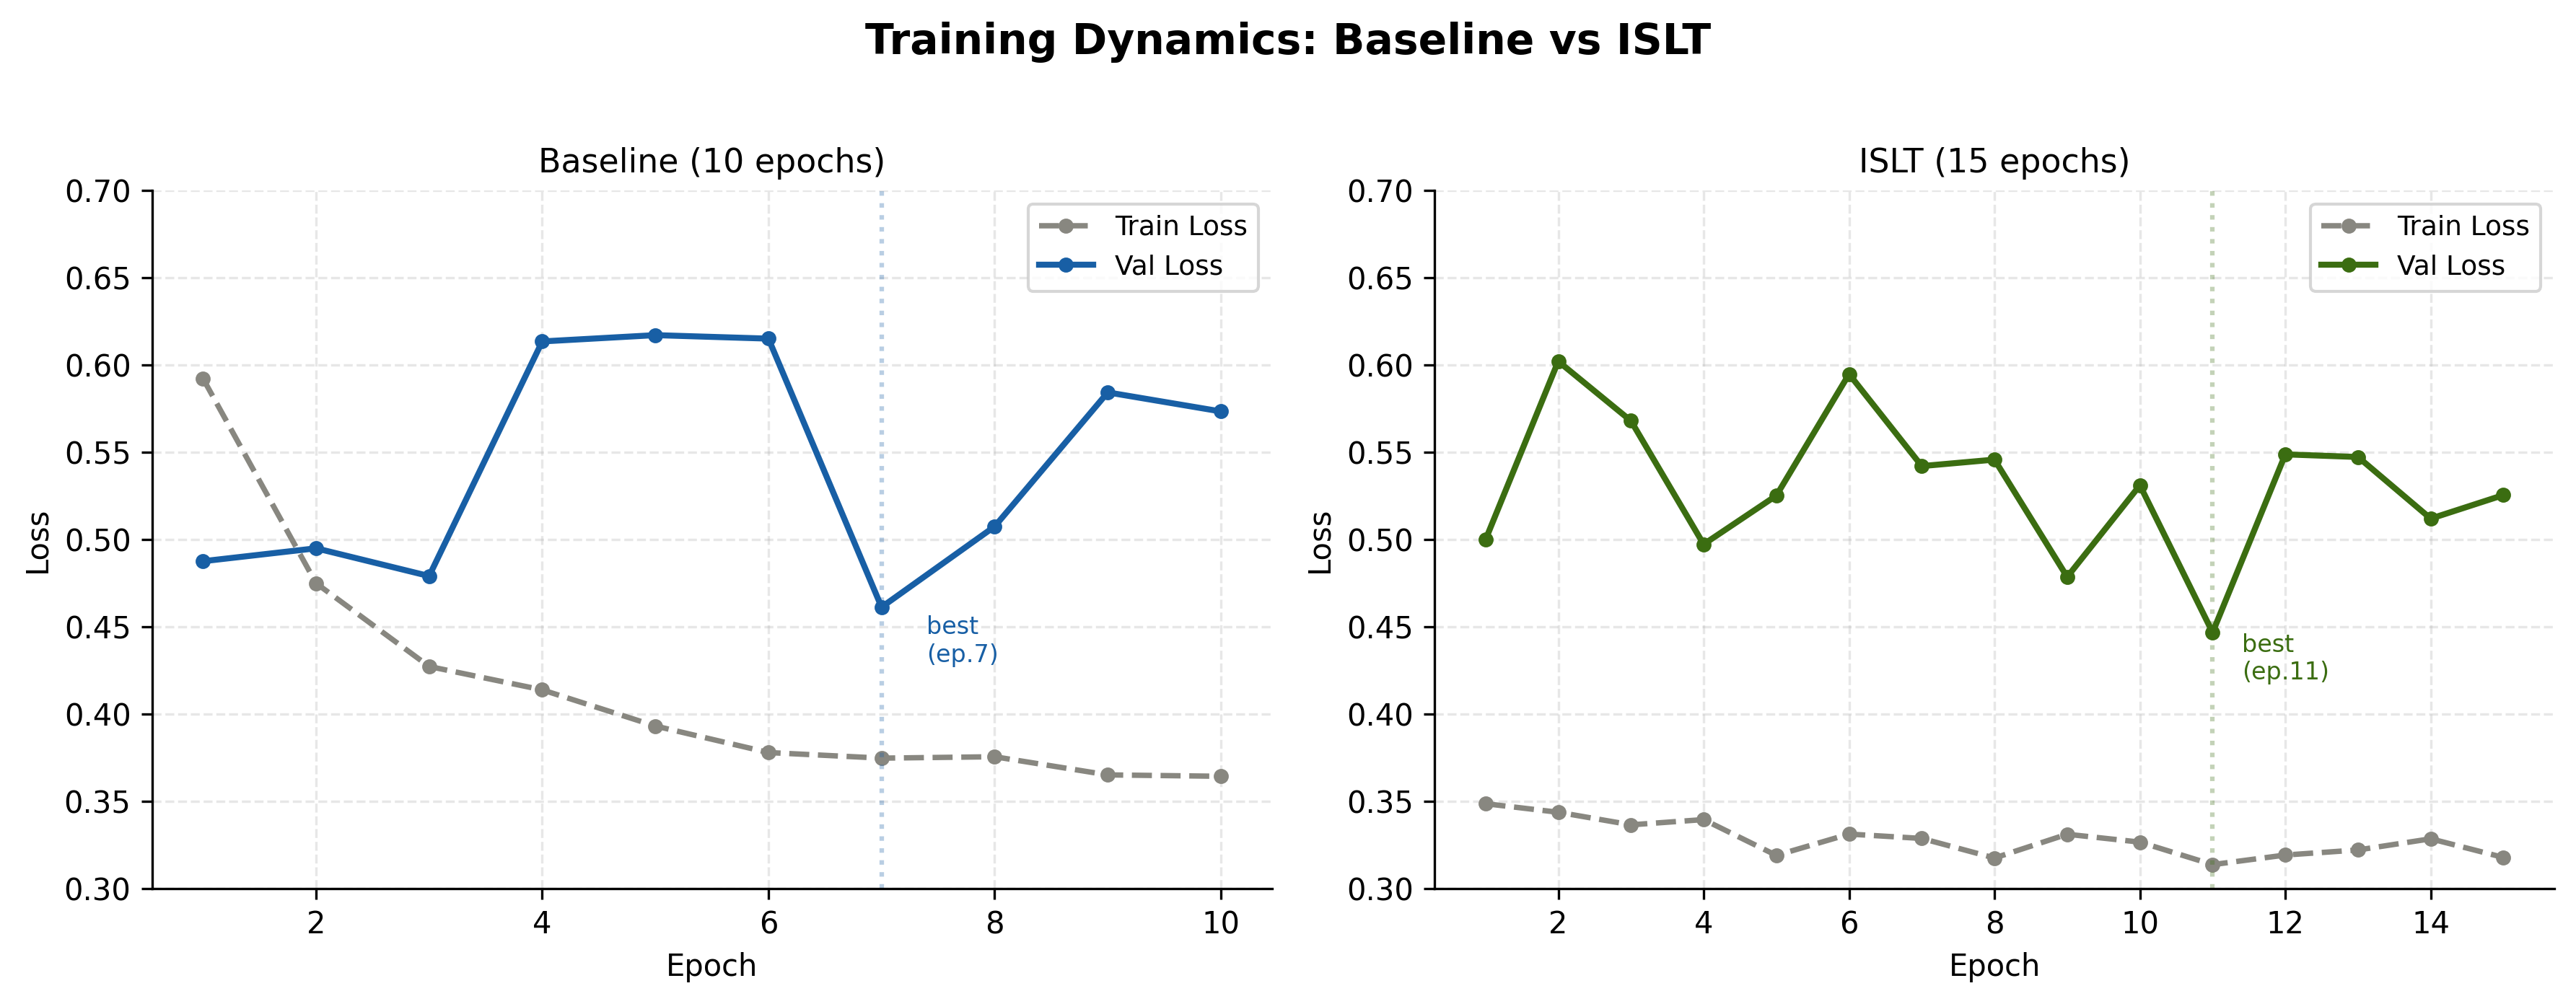

✓ fig1_training_curve.png kaydedildi


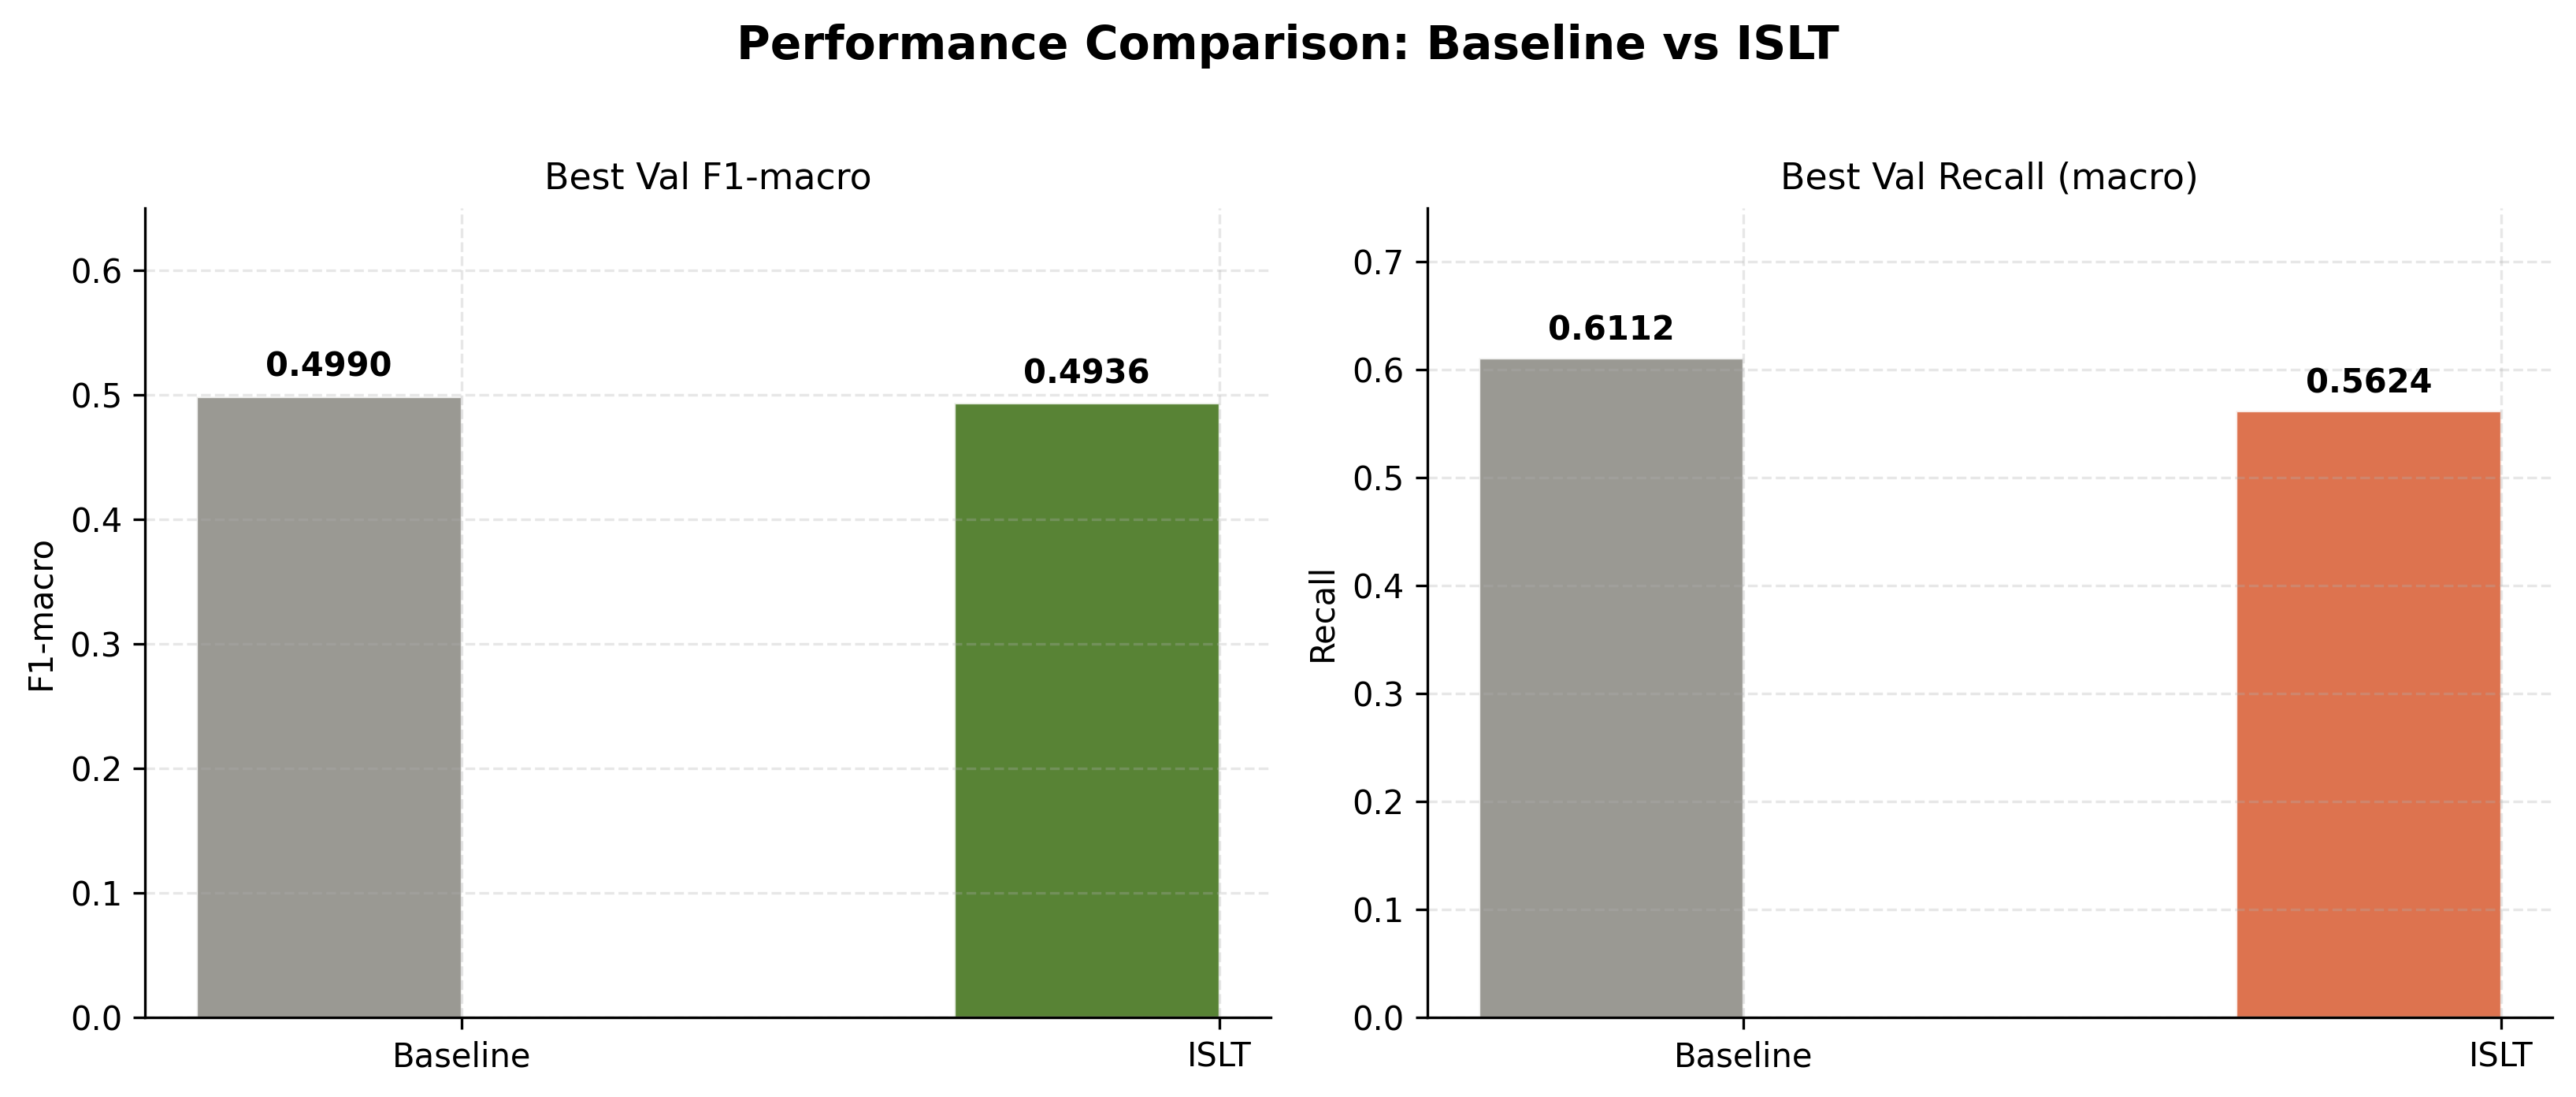

✓ fig2_f1_recall_comparison.png kaydedildi


In [62]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── Veri ─────────────────────────────────────────────────────────────────────
baseline_epochs = list(range(1, 11))
islt_epochs     = list(range(1, 16))

baseline_train_loss = [0.5923,0.4750,0.4273,0.4139,0.3932,0.3780,0.3748,0.3756,0.3652,0.3644]
baseline_val_loss   = [0.4876,0.4950,0.4791,0.6135,0.6171,0.6151,0.4613,0.5075,0.5843,0.5734]
islt_val_loss       = [0.4999,0.6021,0.5680,0.4973,0.5252,0.5948,0.5421,0.5458,0.4786,0.5311,0.4468,0.5488,0.5473,0.5120,0.5255]

baseline_f1     = [0.3810,0.4104,0.4661,0.4551,0.4410,0.4139,0.4206,0.4581,0.4990,0.4688]
islt_f1         = [0.4936,0.4027,0.4588,0.4918,0.4905,0.4697,0.4682,0.4922,0.4505,0.4792,0.4550,0.4412,0.4569,0.4745,0.4745]
baseline_recall = [0.3987,0.4383,0.4656,0.5178,0.5447,0.5230,0.4254,0.5006,0.6112,0.5828]
islt_recall     = [0.5275,0.5074,0.5557,0.5214,0.5284,0.5610,0.5422,0.5624,0.4773,0.5414,0.4788,0.5209,0.5067,0.5019,0.5019]

# ── Stil ──────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'figure.dpi': 300
})

BLUE   = '#185FA5'
GREEN  = '#3B6D11'
GRAY   = '#888780'
CORAL  = '#D85A30'

# ── Figure 1: Training Curve ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle('Training Dynamics: Baseline vs ISLT', fontsize=14, fontweight='bold', y=1.02)

# Sol: Baseline loss
ax = axes[0]
ax.plot(baseline_epochs, baseline_train_loss, color=GRAY, linestyle='--', linewidth=1.8, label='Train Loss', marker='o', markersize=4)
ax.plot(baseline_epochs, baseline_val_loss,   color=BLUE, linewidth=2,   label='Val Loss',   marker='o', markersize=4)
ax.axvline(x=7, color=BLUE, alpha=0.3, linestyle=':', linewidth=1.5)
ax.annotate('best\n(ep.7)', xy=(7, 0.4613), xytext=(7.4, 0.43), fontsize=8, color=BLUE)
ax.set_title('Baseline (10 epochs)', fontsize=11)
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_ylim(0.30, 0.70)
ax.legend(fontsize=9)

# Sağ: ISLT loss
ax = axes[1]
ax.plot(islt_epochs, [0.3487,0.3438,0.3366,0.3396,0.3191,0.3313,0.3288,0.3176,0.3312,0.3267,0.3138,0.3193,0.3222,0.3286,0.3179],
        color=GRAY, linestyle='--', linewidth=1.8, label='Train Loss', marker='o', markersize=4)
ax.plot(islt_epochs, islt_val_loss, color=GREEN, linewidth=2, label='Val Loss', marker='o', markersize=4)
ax.axvline(x=11, color=GREEN, alpha=0.3, linestyle=':', linewidth=1.5)
ax.annotate('best\n(ep.11)', xy=(11, 0.4468), xytext=(11.4, 0.42), fontsize=8, color=GREEN)
ax.set_title('ISLT (15 epochs)', fontsize=11)
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_ylim(0.30, 0.70)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fig1_training_curve.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ fig1_training_curve.png kaydedildi")

# ── Figure 2: F1 & Recall Bar Chart ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
fig.suptitle('Performance Comparison: Baseline vs ISLT', fontsize=14, fontweight='bold', y=1.02)

x     = np.arange(2)
width = 0.35

# Sol: F1 karşılaştırması
ax = axes[0]
bars1 = ax.bar(x - width/2, [max(baseline_f1), max(islt_f1)], width,
               color=[GRAY, GREEN], alpha=0.85, edgecolor='white', linewidth=0.8)
ax.set_title('Best Val F1-macro', fontsize=11)
ax.set_xticks(x); ax.set_xticklabels(['Baseline', 'ISLT'])
ax.set_ylim(0.0, 0.65)
ax.set_ylabel('F1-macro')
for bar, val in zip(bars1, [max(baseline_f1), max(islt_f1)]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Sağ: Recall karşılaştırması
ax = axes[1]
# Best epoch recall (epoch 7 baseline, epoch 1 ISLT)
base_recall_best = baseline_recall[6]   # epoch 7
islt_recall_best = islt_recall[0]       # epoch 1 (en yüksek başlangıç)
islt_recall_max  = max(islt_recall)

bars2 = ax.bar(x - width/2, [max(baseline_recall), max(islt_recall)], width,
               color=[GRAY, CORAL], alpha=0.85, edgecolor='white', linewidth=0.8)
ax.set_title('Best Val Recall (macro)', fontsize=11)
ax.set_xticks(x); ax.set_xticklabels(['Baseline', 'ISLT'])
ax.set_ylim(0.0, 0.75)
ax.set_ylabel('Recall')
for bar, val in zip(bars2, [max(baseline_recall), max(islt_recall)]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fig2_f1_recall_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ fig2_f1_recall_comparison.png kaydedildi")

In [54]:
import matplotlib.pyplot as plt

def plot_training_history(history_islt):
    plt.figure(figsize=(15, 5))

    # Plot Training & Validation Loss
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.title('Training & Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Plot Training & Validation Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history['train_accuracy'], label='Train Accuracy')
    plt.plot(history['val_accuracy'], label='Validation Accuracy')
    plt.title('Training & Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    # Optionally, plot F1-score, Precision, Recall
    if 'val_f1_macro' in history and len(history['val_f1_macro']) > 0:
        plt.figure(figsize=(15, 5))
        plt.plot(history['val_f1_macro'], label='Validation F1-Macro')
        plt.plot(history['val_precision_macro'], label='Validation Precision-Macro')
        plt.plot(history['val_recall_macro'], label='Validation Recall-Macro')
        plt.title('Validation Metrics (F1, Precision, Recall)')
        plt.xlabel('Epoch')
        plt.ylabel('Score')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()


plot_training_history(history_islt)
print("Training history plots generated.")

NameError: name 'history_islt' is not defined

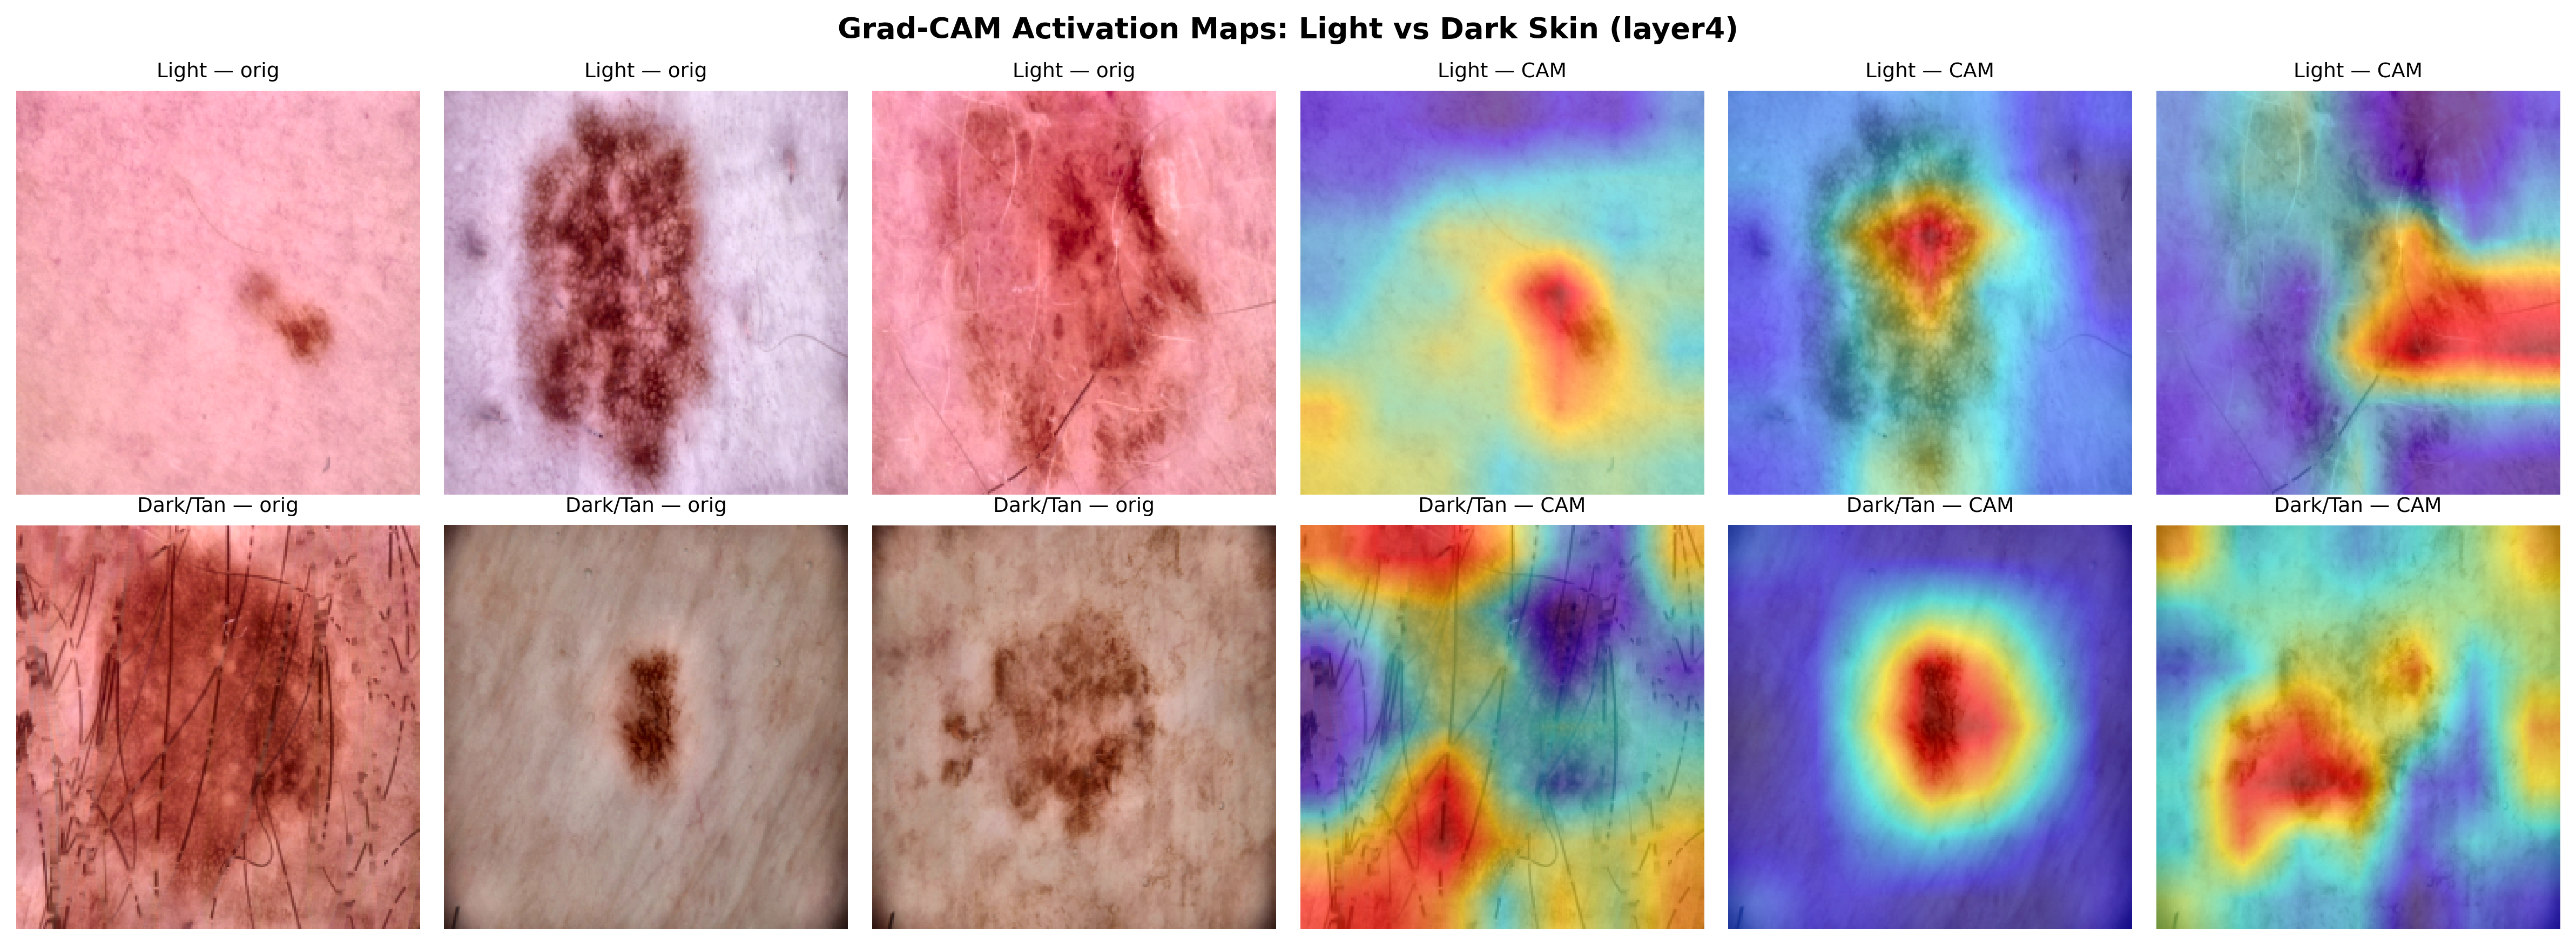

✓ fig3_gradcam_heatmap.png kaydedildi


In [52]:
# ── Figure 3: Grad-CAM Heatmap — Light vs Dark Ten ───────────────────────────
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

def get_gradcam_overlay(img_tensor, meta_tensor, label, target_layer):
    model.eval()

    def forward_no_pool(x):
        for name in ['conv1','bn1','relu','maxpool',
                     'layer1','layer2','layer3','layer4']:
            x = getattr(model.resnet, name)(x)
        return x  # (B, 2048, 7, 7)

    original_forward = model.resnet.forward
    model.resnet.forward = forward_no_pool

    class TempWrapper(torch.nn.Module):
        def __init__(self, base_model, cached_meta):
            super().__init__()
            self.backbone    = base_model.resnet
            self.avgpool     = torch.nn.AdaptiveAvgPool2d((1,1))
            self.fc_layers   = base_model.fc_layers
            self.cached_meta = cached_meta
        def forward(self, x):
            feat = self.backbone(x)
            feat = torch.flatten(self.avgpool(feat), 1)
            meta = self.cached_meta.expand(x.size(0), -1)
            return self.fc_layers(torch.cat([feat, meta], dim=1))

    wrapped = TempWrapper(model, meta_tensor).to(device)
    wrapped.eval()

    for param in target_layer.parameters():
        param.requires_grad_(True)

    with GradCAM(model=wrapped, target_layers=[target_layer]) as cam:
        grayscale = cam(
            input_tensor=img_tensor.unsqueeze(0).to(device),
            targets=[ClassifierOutputTarget(int(label))]
        )

    for param in target_layer.parameters():
        param.requires_grad_(False)

    model.resnet.forward = original_forward
    return grayscale[0]

# Her gruptan 3 örnek seç
np.random.seed(SEED)
light_sample_idx = np.random.choice(light_pos, 3, replace=False)
dark_sample_idx  = np.random.choice(dark_pos,  3, replace=False)

fig, axes = plt.subplots(2, 6, figsize=(16, 6))
fig.suptitle('Grad-CAM Activation Maps: Light vs Dark Skin (layer4)', fontsize=13, fontweight='bold')

val_ds = CustomImageDataset(df_original.reset_index(drop=True), transform=val_test_transform)

def denormalize(tensor):
    mean = np.array([0.7632, 0.5456, 0.5700])
    std  = np.array([0.1403, 0.1529, 0.1702])
    img  = tensor.permute(1,2,0).numpy()
    img  = img * std + mean
    return np.clip(img, 0, 1).astype(np.float32)

for col, idx in enumerate(light_sample_idx):
    img_tensor, meta, label, _ = val_ds[int(idx)]
    rgb     = denormalize(img_tensor)
    cam_map = get_gradcam_overlay(img_tensor, meta.unsqueeze(0).to(device), label, model.resnet.layer4)
    overlay = show_cam_on_image(rgb, cam_map, use_rgb=True)
    axes[0, col].imshow(rgb);     axes[0, col].set_title('Light — orig', fontsize=9);  axes[0, col].axis('off')
    axes[0, col+3].imshow(overlay); axes[0, col+3].set_title('Light — CAM', fontsize=9); axes[0, col+3].axis('off')

for col, idx in enumerate(dark_sample_idx):
    img_tensor, meta, label, _ = val_ds[int(idx)]
    rgb     = denormalize(img_tensor)
    cam_map = get_gradcam_overlay(img_tensor, meta.unsqueeze(0).to(device), label, model.resnet.layer4)
    overlay = show_cam_on_image(rgb, cam_map, use_rgb=True)
    axes[1, col].imshow(rgb);     axes[1, col].set_title('Dark/Tan — orig', fontsize=9);  axes[1, col].axis('off')
    axes[1, col+3].imshow(overlay); axes[1, col+3].set_title('Dark/Tan — CAM', fontsize=9); axes[1, col+3].axis('off')

axes[0,0].set_ylabel('Light skin', fontsize=10, fontweight='bold')
axes[1,0].set_ylabel('Dark/Tan skin', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fig3_gradcam_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ fig3_gradcam_heatmap.png kaydedildi")

## Bölüm 17 — Baseline vs ISLT Karşılaştırma

Koyu tenli örneklerde iki modelin F1 ve doğruluk skorları karşılaştırılır.

In [63]:
# ISLT modeline geç
model.load_state_dict(torch.load('/content/drive/MyDrive/best_model_islt.pth', map_location=device))
for name, param in model.resnet.named_parameters():
    if 'layer4' in name:
        param.requires_grad = True
model.eval()
print("✓ ISLT modeli yüklendi")

✓ ISLT modeli yüklendi


In [64]:
# Hangi model yüklü?
import os
baseline_path = '/content/drive/MyDrive/best_model_baseline.pth'
islt_path     = '/content/drive/MyDrive/best_model_islt.pth'

print(f"baseline boyutu : {os.path.getsize(baseline_path):,} bytes")
print(f"islt boyutu     : {os.path.getsize(islt_path):,} bytes")

# Şu an modelde kaç parametre eğitilebilir?
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nŞu an trainable params: {trainable:,}")

# Son katman ağırlıklarına bak — iki model farklıysa değerler farklı olmalı
import torch
baseline_state = torch.load(baseline_path, map_location=device)
islt_state     = torch.load(islt_path, map_location=device)

# fc_layers son katmanını karşılaştır
key = 'fc_layers.6.weight'
diff = (baseline_state[key] - islt_state[key]).abs().sum().item()
print(f"\nfc_layers son katman farkı (baseline vs islt): {diff:.6f}")
print("0 ise aynı model yüklü, >0 ise farklı")

baseline boyutu : 99,091,823 bytes
islt boyutu     : 99,090,503 bytes

Şu an trainable params: 16,147,975

fc_layers son katman farkı (baseline vs islt): 73.736656
0 ise aynı model yüklü, >0 ise farklı


=== Baseline vs ISLT — Cilt Tipine Göre Doğruluk ===
              Baseline      ISLT  Fark (+ISLT)
skin_type                                     
Brown         1.000000  1.000000           0.0
Dark          1.000000  1.000000           0.0
Intermediate  1.000000  1.000000           0.0
Light         0.928571  0.928571           0.0
Very Light    0.805226  0.805226           0.0


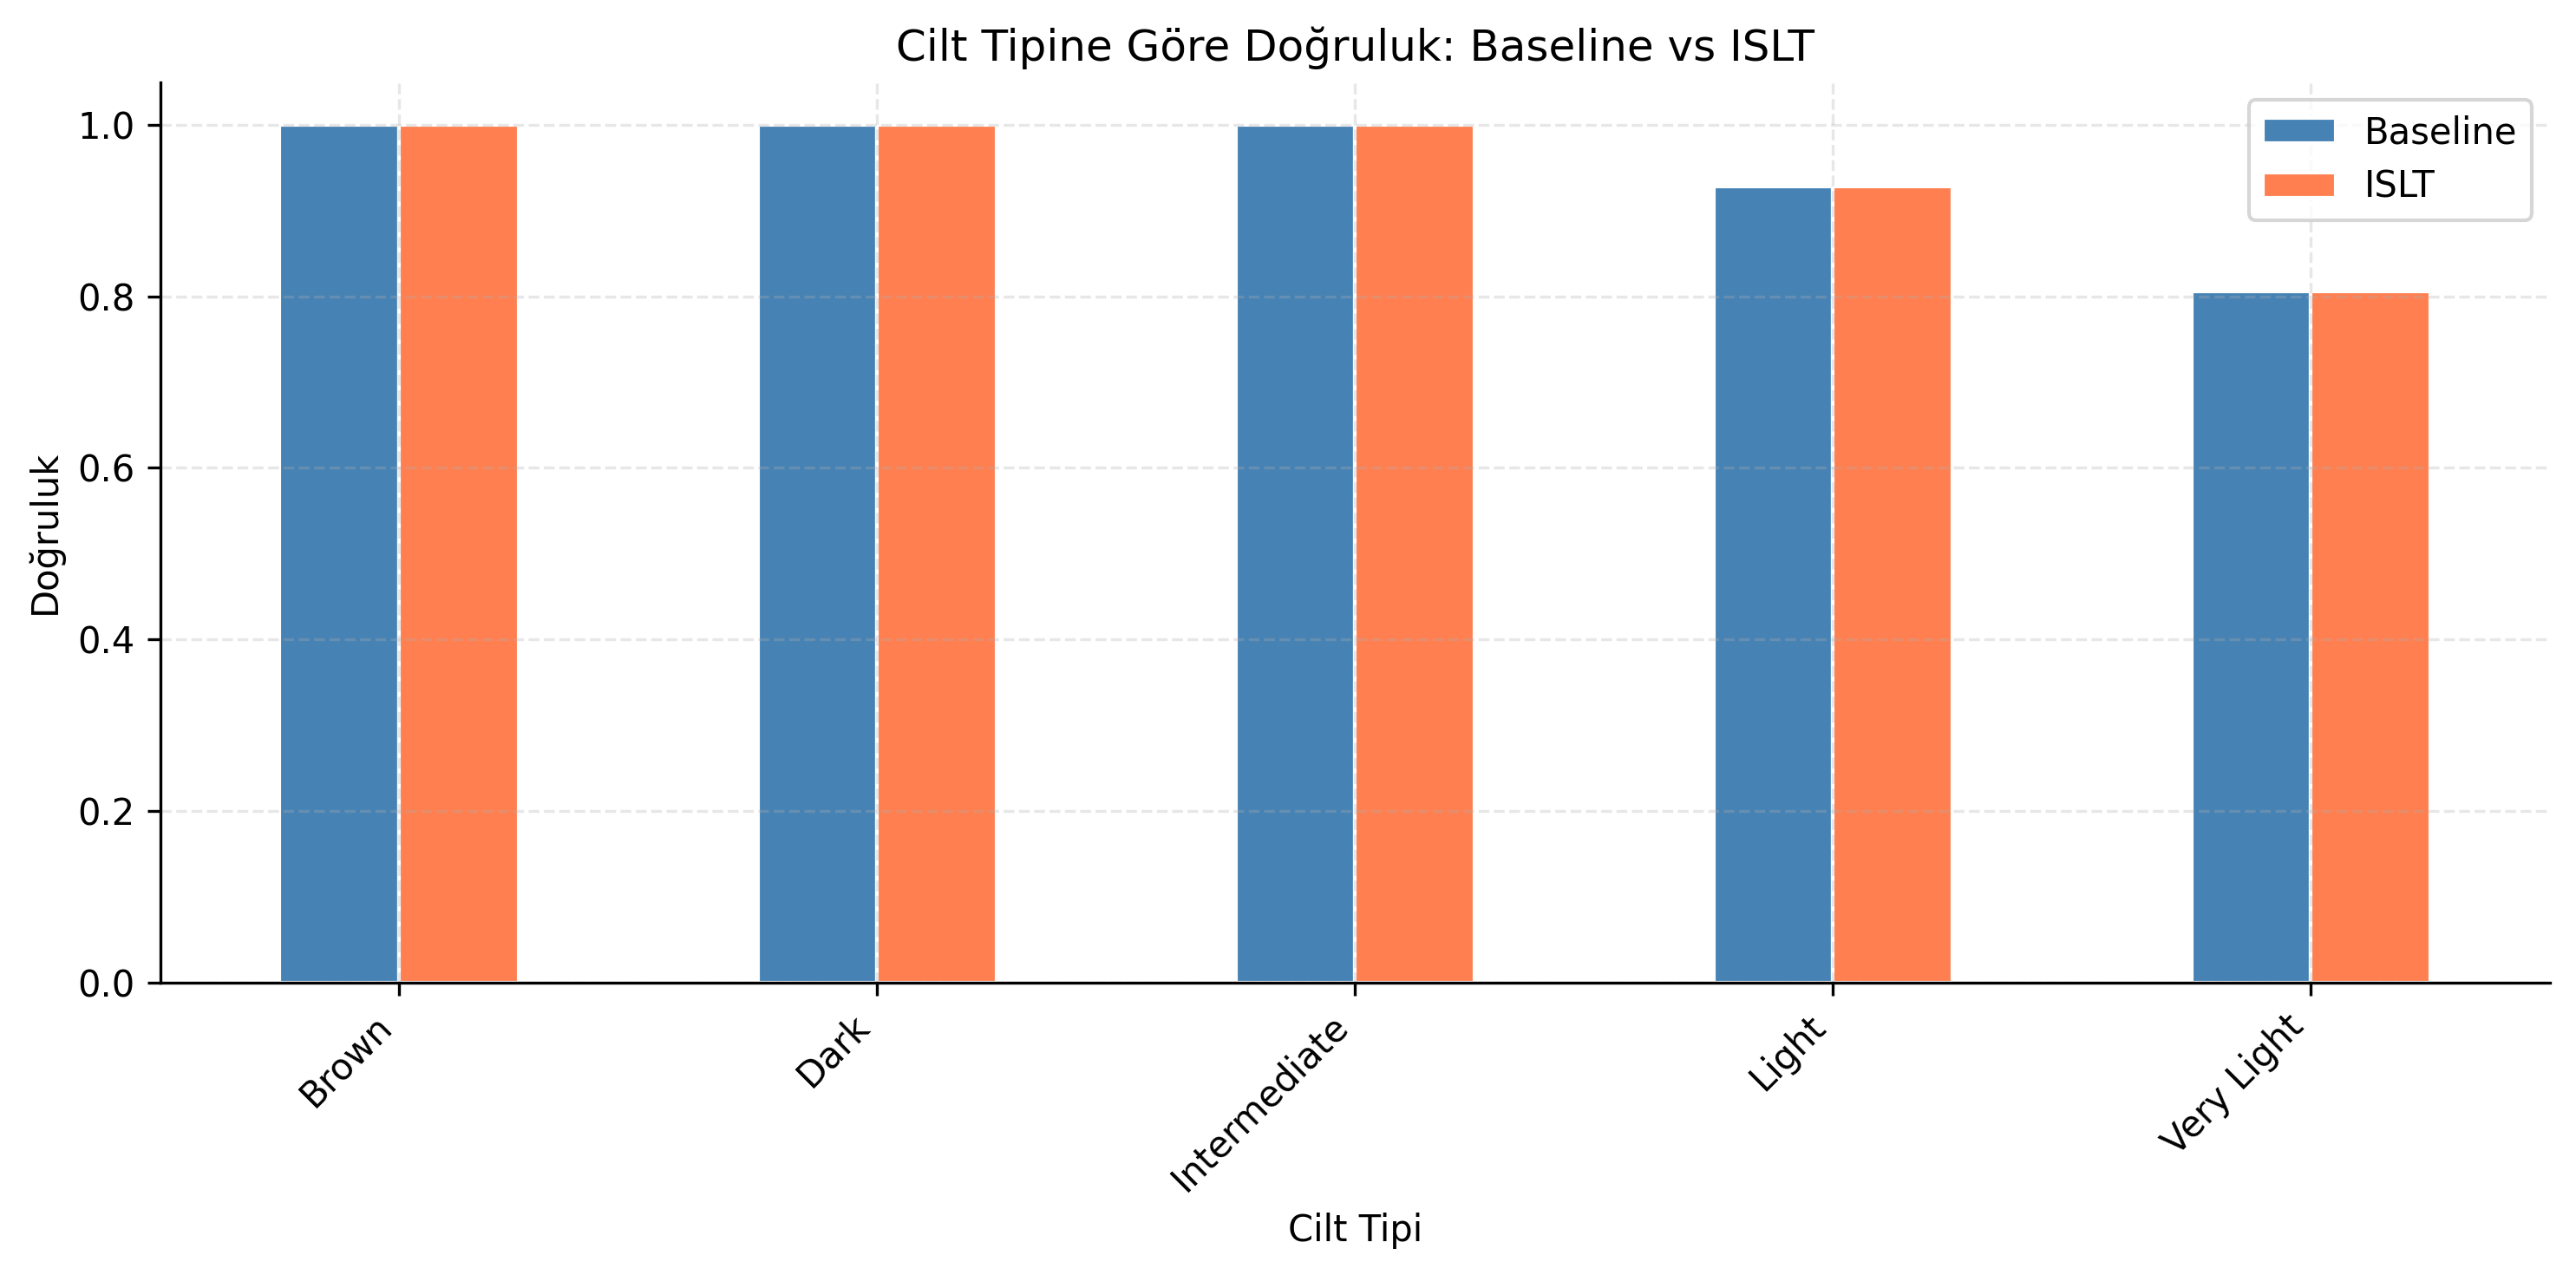


Koyu Ten (Brown+Dark) F1-macro:
  Baseline : 1.0000
  ISLT     : 1.0000
  Fark     : +0.0000

=== EOD — ISLT ===
  TPR Light/Intermediate : 0.4527  (n=552)
  TPR Tan/Brown/Dark     : 1.0000  (n=3)
  EOD (dark - light)     : +0.5473
  → Model koyu tende daha iyi performans gösteriyor.

=== EOD Karşılaştırması ===
  Baseline EOD : +0.5473
  ISLT EOD     : +0.5473
  İyileşme     : +0.0000
  → ISLT fairness üzerinde beklenen etkiyi göstermedi.


In [65]:
import matplotlib.pyplot as plt

# ISLT sonrası bias analizi
model.eval()
islt_preds  = []
islt_labels = []
islt_skin   = []

with torch.no_grad():
    for images, meta_data, labels, skin_types in test_dataloader:
        images    = images.to(device)
        meta_data = meta_data.to(device)
        outputs   = model(images, meta_data)
        _, predicted = torch.max(outputs, 1)
        islt_preds.extend(predicted.cpu().numpy())
        islt_labels.extend(labels.cpu().numpy())
        islt_skin.extend(skin_types)

islt_df = pd.DataFrame({'pred': islt_preds, 'label': islt_labels, 'skin_type': islt_skin})
islt_df['correct'] = (islt_df['pred'] == islt_df['label']).astype(int)

# Karşılaştırma tablosu
print("=== Baseline vs ISLT — Cilt Tipine Göre Doğruluk ===")
baseline_acc = results_df.groupby('skin_type')['correct'].mean()
islt_acc     = islt_df.groupby('skin_type')['correct'].mean()

comparison = pd.DataFrame({'Baseline': baseline_acc, 'ISLT': islt_acc})
comparison['Fark (+ISLT)'] = comparison['ISLT'] - comparison['Baseline']
print(comparison.sort_values('Fark (+ISLT)'))

# Grafik
comparison[['Baseline', 'ISLT']].plot(
    kind='bar', figsize=(10, 5), color=['steelblue', 'coral'], edgecolor='white')
plt.title('Cilt Tipine Göre Doğruluk: Baseline vs ISLT')
plt.xlabel('Cilt Tipi')
plt.ylabel('Doğruluk')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

# Koyu ten özelinde F1 karşılaştırması
dark_mask_islt = islt_df['skin_type'].isin(['Brown', 'Dark'])
dark_islt_df   = islt_df[dark_mask_islt]
dark_mask_base = results_df['skin_type'].isin(['Brown', 'Dark'])
dark_base_df   = results_df[dark_mask_base]

if len(dark_islt_df) > 0 and len(dark_base_df) > 0:
    f1_base = f1_score(dark_base_df['label'], dark_base_df['pred'], average='macro', zero_division=0)
    f1_islt = f1_score(dark_islt_df['label'], dark_islt_df['pred'], average='macro', zero_division=0)
    print(f"\nKoyu Ten (Brown+Dark) F1-macro:")
    print(f"  Baseline : {f1_base:.4f}")
    print(f"  ISLT     : {f1_islt:.4f}")
    print(f"  Fark     : {f1_islt - f1_base:+.4f}")


# ── Kritik 4 — EOD: ISLT sonrası ────────────────────────────────────────────
eod_islt = compute_eod(islt_df, label='ISLT')

if eod_baseline is not None and eod_islt is not None:
    print(f'\n=== EOD Karşılaştırması ===')
    print(f'  Baseline EOD : {eod_baseline:+.4f}')
    print(f'  ISLT EOD     : {eod_islt:+.4f}')
    print(f'  İyileşme     : {eod_islt - eod_baseline:+.4f}')
    if eod_islt > eod_baseline:
        print('  → ISLT fairness bias azalttı.')
    else:
        print('  → ISLT fairness üzerinde beklenen etkiyi göstermedi.')


In [66]:
# Validation seti üzerinden EOD — daha fazla koyu ten örneği var
model.load_state_dict(torch.load('/content/drive/MyDrive/best_model_baseline.pth', map_location=device))
model.eval()

# Baseline — valid set
val_preds_b, val_labels_b, val_skin_b = [], [], []
with torch.no_grad():
    for images, meta, labels, skin_types in valid_dataloader:
        images, meta, labels = images.to(device), meta.to(device), labels.to(device)
        outputs = model(images, meta)
        _, predicted = torch.max(outputs, 1)
        val_preds_b.extend(predicted.cpu().numpy())
        val_labels_b.extend(labels.cpu().numpy())
        val_skin_b.extend(skin_types)

import pandas as pd
val_df_base = pd.DataFrame({'pred': val_preds_b, 'label': val_labels_b, 'skin_type': val_skin_b})
eod_val_baseline = compute_eod(val_df_base, label='Baseline (val)')

# ISLT — valid set
model.load_state_dict(torch.load('/content/drive/MyDrive/best_model_islt.pth', map_location=device))
model.eval()

val_preds_i, val_labels_i, val_skin_i = [], [], []
with torch.no_grad():
    for images, meta, labels, skin_types in valid_dataloader:
        images, meta, labels = images.to(device), meta.to(device), labels.to(device)
        outputs = model(images, meta)
        _, predicted = torch.max(outputs, 1)
        val_preds_i.extend(predicted.cpu().numpy())
        val_labels_i.extend(labels.cpu().numpy())
        val_skin_i.extend(skin_types)

val_df_islt = pd.DataFrame({'pred': val_preds_i, 'label': val_labels_i, 'skin_type': val_skin_i})
eod_val_islt = compute_eod(val_df_islt, label='ISLT (val)')

print(f'\n=== Validation EOD Karşılaştırması ===')
print(f'  Baseline EOD : {eod_val_baseline:+.4f}')
print(f'  ISLT EOD     : {eod_val_islt:+.4f}')
print(f'  İyileşme     : {eod_val_islt - eod_val_baseline:+.4f}')


=== EOD — Baseline (val) ===
  TPR Light/Intermediate : 0.4477  (n=549)
  TPR Tan/Brown/Dark     : 0.0000  (n=2)
  EOD (dark - light)     : -0.4477
  → Model koyu tende belirgin bias gösteriyor.

=== EOD — ISLT (val) ===
  TPR Light/Intermediate : 0.4798  (n=549)
  TPR Tan/Brown/Dark     : 0.0000  (n=2)
  EOD (dark - light)     : -0.4798
  → Model koyu tende belirgin bias gösteriyor.

=== Validation EOD Karşılaştırması ===
  Baseline EOD : -0.4477
  ISLT EOD     : -0.4798
  İyileşme     : -0.0322
